In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re

In [ ]:
df=pd.read_csv("/content/Superstore.csv",encoding='latin1')

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [ ]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [ ]:
cols_to_check_unique_values=["Segment","Country","City","State","Region","Category","Sub-Category","Quantity"]
for i in cols_to_check_unique_values:
  print(f"UNIQUE VALUES IN {i} ARE: {df[i].unique()}\n")
# df["Quantity"].unique()

UNIQUE VALUES IN Segment ARE: ['Consumer' 'Corporate' 'Home Office']

UNIQUE VALUES IN Country ARE: ['United States']

UNIQUE VALUES IN City ARE: ['Henderson' 'Los Angeles' 'Fort Lauderdale' 'Concord' 'Seattle'
 'Fort Worth' 'Madison' 'West Jordan' 'San Francisco' 'Fremont'
 'Philadelphia' 'Orem' 'Houston' 'Richardson' 'Naperville' 'Melbourne'
 'Eagan' 'Westland' 'Dover' 'New Albany' 'New York City' 'Troy' 'Chicago'
 'Gilbert' 'Springfield' 'Jackson' 'Memphis' 'Decatur' 'Durham' 'Columbia'
 'Rochester' 'Minneapolis' 'Portland' 'Saint Paul' 'Aurora' 'Charlotte'
 'Orland Park' 'Urbandale' 'Columbus' 'Bristol' 'Wilmington' 'Bloomington'
 'Phoenix' 'Roseville' 'Independence' 'Pasadena' 'Newark' 'Franklin'
 'Scottsdale' 'San Jose' 'Edmond' 'Carlsbad' 'San Antonio' 'Monroe'
 'Fairfield' 'Grand Prairie' 'Redlands' 'Hamilton' 'Westfield' 'Akron'
 'Denver' 'Dallas' 'Whittier' 'Saginaw' 'Medina' 'Dublin' 'Detroit'
 'Tampa' 'Santa Clara' 'Lakeville' 'San Diego' 'Brentwood' 'Chapel Hill'
 'Morrist

In [ ]:
int_cols=[]
for i in df.columns:
  if df[i].dtype == "int64":
    int_cols.append(i)
print(int_cols)

['Row ID', 'Postal Code', 'Quantity']


In [ ]:
for i in int_cols:
  df[i]=df[i].replace(" ","")


In [ ]:
df["Order Date"]=pd.to_datetime(df["Order Date"],format="mixed")
df["Ship Date"]=pd.to_datetime(df["Ship Date"],format="mixed")

In [ ]:
def clean_string(i):
    i= str(i)
    i= i.strip()
    i= re.sub(r"\s+", " ", i)
    return i


In [ ]:
for i in df.columns:
  if df[i].dtype == "object":
    df[i]=df[i].apply(clean_string)

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df["Sales"]=df["Sales"].round(0)
df["Profit"]=df["Profit"].round(0)

In [ ]:
df["Discount"]=df["Discount"]*100

In [ ]:
import sqlite3

In [ ]:
conn=sqlite3.connect("Store.db")

In [ ]:
df.to_sql("store", conn,if_exists="replace")

9994

In [ ]:
query="""
SELECT * FROM store
limit 3
"""
print(pd.read_sql(query,conn))

   index  Row ID        Order ID           Order Date            Ship Date  \
0      0       1  CA-2016-152156  2016-11-08 00:00:00  2016-11-11 00:00:00   
1      1       2  CA-2016-152156  2016-11-08 00:00:00  2016-11-11 00:00:00   
2      2       3  CA-2016-138688  2016-06-12 00:00:00  2016-06-16 00:00:00   

      Ship Mode Customer ID    Customer Name    Segment        Country  ...  \
0  Second Class    CG-12520      Claire Gute   Consumer  United States  ...   
1  Second Class    CG-12520      Claire Gute   Consumer  United States  ...   
2  Second Class    DV-13045  Darrin Van Huff  Corporate  United States  ...   

  Postal Code Region       Product ID         Category Sub-Category  \
0       42420  South  FUR-BO-10001798        Furniture    Bookcases   
1       42420  South  FUR-CH-10000454        Furniture       Chairs   
2       90036   West  OFF-LA-10000240  Office Supplies       Labels   

                                        Product Name  Sales Quantity  \
0            

In [ ]:
# sales per year per month
# profit per year per month
# Top sales in terms of city
# top selling category
# most profitable category
# region with most buyers
# longest time taken to deliver
# Shortest time taken to deliver
# Ranking Shipping modes
# "segment" - biggest buyers, most number of sales, their favourite Shipping mode
# most selling sub category of a particular category
# most profitable sub category of a particular category
# Category and sub-category with highest discounts
# most frequent Shiping modes per city
# most frequent Shiping modes per region

In [ ]:
# Top sales in terms of city
q="""
select City,sum(Sales) as total_sales from store
group by City
order by total_sales desc
limit 10
"""
print(pd.read_sql(q,conn))

            City  total_sales
0  New York City     256394.0
1    Los Angeles     175856.0
2        Seattle     119552.0
3  San Francisco     112689.0
4   Philadelphia     109085.0
5        Houston      64504.0
6        Chicago      48540.0
7      San Diego      47521.0
8   Jacksonville      44712.0
9    Springfield      43052.0


In [ ]:
print(f"Total Sales: ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Total Orders: {df['Order ID'].nunique():,}")
print(f"Total Customers: {df['Customer ID'].nunique():,}")
print(f"Total Products: {df['Product Name'].nunique():,}")
print(f"Total Productss: {df['Product ID'].nunique():,}")
print(f"Average Order Value: ${df['Sales'].mean():,.2f}")

Total Sales: $2,297,340.00
Total Profit: $286,340.00
Total Orders: 5,009
Total Customers: 793
Total Products: 1,850
Total Productss: 1,862
Average Order Value: $229.87


In [ ]:
q="""
SELECT
    ROUND(SUM(Sales), 2) AS Total_Sales
FROM store;
"""
print(pd.read_sql(q,conn))

   Total_Sales
0    2297340.0


In [ ]:
q="""
SELECT
    COUNT(DISTINCT "Order ID") AS Total_Orders
FROM store;
"""
print(pd.read_sql(q,conn))


   Total_Orders
0          5009


In [ ]:
# top selling category
q="""
select Category,sum(Sales) as total_sales from store
group by Category
order by total_sales desc
limit 10
"""
print(pd.read_sql(q,conn))

          Category  total_sales
0       Technology     836219.0
1        Furniture     742003.0
2  Office Supplies     719118.0


In [ ]:
q="""
SELECT
    Category,
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM store
GROUP BY Category
ORDER BY Total_Profit DESC;
"""
print(pd.read_sql(q,conn))

          Category  Total_Profit
0       Technology      145423.0
1  Office Supplies      122473.0
2        Furniture       18444.0


### When we check Categorically, Technology gets the highest sales as well as Profit. Whereas, Furniture yeilds the least profit even though it does better than Office Supplies when it comes to Sales.

In [ ]:
q="""
SELECT
    Region,
    ROUND(SUM(Sales), 2) AS Total_Sales
FROM store
GROUP BY Region
ORDER BY Total_Sales DESC;
"""
print(pd.read_sql(q,conn))

    Region  Total_Sales
0     West     725511.0
1     East     678828.0
2  Central     501253.0
3    South     391748.0


In [ ]:
q="""
SELECT
    Region,
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM store
GROUP BY Region
ORDER BY Total_Profit DESC;
"""
print(pd.read_sql(q,conn))

    Region  Total_Profit
0     West      108383.0
1     East       91518.0
2    South       46721.0
3  Central       39718.0


### While checking region-wise, the WEST region Dominates in Sales with 725,511 as well as Profit with 108,383 followed by EAST Region providing 678,828 in Sales and 91,518 in Profit. Following that with  CENTRAL and SOUTH regions in Sales but swithes position in Profit resulting CENTRAL region to last position, contributing 39,718 in profit.

In [ ]:
q="""
SELECT
    State,
    ROUND(SUM(Sales), 2) AS Total_Sales
FROM store
GROUP BY State
ORDER BY Total_Sales DESC;
"""
print(pd.read_sql(q,conn))

                   State  Total_Sales
0             California     457728.0
1               New York     310911.0
2                  Texas     170187.0
3             Washington     138656.0
4           Pennsylvania     116522.0
5                Florida      89479.0
6               Illinois      80162.0
7                   Ohio      78253.0
8               Michigan      76280.0
9               Virginia      70641.0
10        North Carolina      55604.0
11               Indiana      53549.0
12               Georgia      49102.0
13              Kentucky      36598.0
14            New Jersey      35763.0
15               Arizona      35283.0
16             Wisconsin      32124.0
17              Colorado      32110.0
18             Tennessee      30662.0
19             Minnesota      29865.0
20         Massachusetts      28639.0
21              Delaware      27451.0
22              Maryland      23706.0
23          Rhode Island      22629.0
24              Missouri      22207.0
25          

In [ ]:
q="""
SELECT
    State,
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM store
GROUP BY State
ORDER BY Total_Profit DESC;
"""
print(pd.read_sql(q,conn))

                   State  Total_Profit
0             California       76367.0
1               New York       74018.0
2             Washington       33389.0
3               Michigan       24458.0
4               Virginia       18600.0
5                Indiana       18382.0
6                Georgia       16247.0
7               Kentucky       11202.0
8              Minnesota       10828.0
9               Delaware        9979.0
10            New Jersey        9771.0
11             Wisconsin        8400.0
12          Rhode Island        7286.0
13              Maryland        7032.0
14         Massachusetts        6782.0
15              Missouri        6435.0
16               Alabama        5785.0
17              Oklahoma        4852.0
18              Arkansas        4006.0
19           Connecticut        3510.0
20                Nevada        3316.0
21           Mississippi        3172.0
22                  Utah        2546.0
23               Vermont        2247.0
24             Louisiana 

### In State-wise contribution we notice that California, New York, Texas and Washington holds the top 4 positions in sales but when it comes to Profit, Texas holds the last position contributing the loss of 25,715. The rest remains almost as expected.

In [ ]:
q="""
SELECT
    City,
    ROUND(SUM(Sales), 2) AS Total_Sales
FROM store
GROUP BY City
ORDER BY Total_Sales DESC
limit 20;
"""
print(pd.read_sql(q,conn))

             City  Total_Sales
0   New York City     256394.0
1     Los Angeles     175856.0
2         Seattle     119552.0
3   San Francisco     112689.0
4    Philadelphia     109085.0
5         Houston      64504.0
6         Chicago      48540.0
7       San Diego      47521.0
8    Jacksonville      44712.0
9     Springfield      43052.0
10        Detroit      42452.0
11       Columbus      38698.0
12         Newark      28575.0
13       Columbia      25288.0
14      Lafayette      25035.0
15        Jackson      24965.0
16    San Antonio      21848.0
17     Burlington      21668.0
18      Arlington      20218.0
19         Dallas      20129.0


In [ ]:
q="""
SELECT City,
ROUND(SUM(Profit), 2) AS Total_Profit
FROM store
GROUP BY City
ORDER BY Total_Profit
limit 10;
"""
print(pd.read_sql(q,conn))

           City  Total_Profit
0  Philadelphia      -13832.0
1       Houston      -10147.0
2   San Antonio       -7300.0
3     Lancaster       -7237.0
4       Chicago       -6651.0
5    Burlington       -3620.0
6        Dallas       -2843.0
7       Phoenix       -2793.0
8        Aurora       -2695.0
9  Jacksonville       -2329.0


### When we see City-wise, certain cities like Philadelphia, Houston, Chicago and Jacksonville which are at the top 10 in the Sale's list but are in the bottom 10 in the Profit's list.

In [ ]:
q="""
SELECT
    "Customer Name",
    ROUND(SUM(Sales), 2) AS Total_Sales
FROM store
GROUP BY "Customer Name"
ORDER BY Total_Sales DESC
limit 40;
"""
print(pd.read_sql(q,conn))

           Customer Name  Total_Sales
0            Sean Miller      25042.0
1           Tamara Chand      19050.0
2           Raymond Buch      15117.0
3           Tom Ashbrook      14596.0
4          Adrian Barton      14476.0
5           Ken Lonsdale      14175.0
6           Sanjit Chand      14145.0
7           Hunter Lopez      12875.0
8           Sanjit Engle      12209.0
9     Christopher Conant      12128.0
10          Todd Sumrall      11891.0
11             Greg Tran      11821.0
12          Becky Martin      11791.0
13           Seth Vernon      11472.0
14       Caroline Jumper      11165.0
15           Clay Ludtke      10881.0
16         Maria Etezadi      10665.0
17        Karen Ferguson      10606.0
18          Bill Shonely      10502.0
19          Edward Hooks      10313.0
20              John Lee       9799.0
21        Grant Thornton       9351.0
22       Helen Wasserman       9299.0
23      Tom Boeckenhauer       9134.0
24          Peter Fuller       9065.0
25  Christop

In [ ]:
q="""
SELECT
    "Customer Name",
    ROUND(SUM(Profit), 2) AS Total_Profit
FROM store
GROUP BY "Customer Name"
ORDER BY Total_Profit asc
limit 20;
"""
print(pd.read_sql(q,conn))

       Customer Name  Total_Profit
0      Cindy Stewart       -6625.0
1     Grant Thornton       -4109.0
2        Luke Foster       -3583.0
3     Sharelle Roach       -3336.0
4      Henry Goldwyn       -2797.0
5        Nathan Cano       -2204.0
6       Sean Braxton       -2082.0
7        Sean Miller       -1981.0
8     Christine Phan       -1852.0
9   Natalie Fritzler       -1697.0
10      Becky Martin       -1660.0
11   Tracy Blumstein       -1601.0
12      Dan Campbell       -1440.0
13      David Bremer       -1422.0
14      Rose O'Brian       -1263.0
15      Tom Prescott       -1088.0
16  Zuschuss Carroll       -1032.0
17  Victoria Pisteka       -1019.0
18   Shahid Shariari       -1012.0
19       Olvera Toch        -924.0


In [ ]:
# Sean MIller

In [ ]:
q="""
select "Product ID","Product Name",
sum(Sales) as total_sales
from store
group by "Product ID", "Product Name"
order by total_sales desc
limit 20
"""
print(pd.read_sql(q,conn))

         Product ID                                       Product Name  \
0   TEC-CO-10004722              Canon imageCLASS 2200 Advanced Copier   
1   OFF-BI-10003527  Fellowes PB500 Electric Punch Plastic Comb Bin...   
2   TEC-MA-10002412  Cisco TelePresence System EX90 Videoconferenci...   
3   FUR-CH-10002024       HON 5400 Series Task Chairs for Big and Tall   
4   OFF-BI-10001359         GBC DocuBind TL300 Electric Binding System   
5   OFF-BI-10000545   GBC Ibimaster 500 Manual ProClick Binding System   
6   TEC-CO-10001449               Hewlett Packard LaserJet 3310 Copier   
7   TEC-MA-10001127  HP Designjet T520 Inkjet Large Format Printer ...   
8   OFF-BI-10004995          GBC DocuBind P400 Electric Binding System   
9   OFF-SU-10000151        High Speed Automatic Electric Letter Opener   
10  TEC-MA-10000822          Lexmark MX611dhe Monochrome Laser Printer   
11  OFF-SU-10002881  Martin Yale Chadless Opener Electric Letter Op...   
12  OFF-BI-10001120               Ibic

In [ ]:
q="""
select "Product ID","Category","Discount","Product Name",
sum(Profit) as total_Profit
from store
group by "Product ID", "Product Name"
order by total_Profit Asc
limit 20;
"""
print(pd.read_sql(q,conn))

         Product ID         Category  Discount  \
0   TEC-MA-10000418       Technology      70.0   
1   TEC-MA-10000822       Technology      40.0   
2   TEC-MA-10004125       Technology      50.0   
3   FUR-TA-10000198        Furniture       0.0   
4   FUR-TA-10001889        Furniture      50.0   
5   OFF-BI-10004995  Office Supplies      20.0   
6   TEC-MA-10002412       Technology      50.0   
7   OFF-SU-10002881  Office Supplies      20.0   
8   FUR-TA-10001950        Furniture       0.0   
9   FUR-TA-10004289        Furniture      50.0   
10  FUR-TA-10004154        Furniture      40.0   
11  TEC-MA-10002210       Technology      70.0   
12  FUR-CH-10003312        Furniture      30.0   
13  FUR-BO-10001972        Furniture      15.0   
14  FUR-TA-10004256        Furniture      20.0   
15  TEC-MA-10001695       Technology      70.0   
16  OFF-AP-10002534  Office Supplies      80.0   
17  FUR-TA-10002958        Furniture      50.0   
18  OFF-ST-10004459  Office Supplies       0.0   


In [ ]:
# Bottom 4 products gives the around loss of 20,000
# Chromcraft gives the -2800 even when there is no discounts


In [ ]:
q="""
select "Product ID","Product Name",
sum(Sales) as total_sales
from store
group by "Product ID", "Product Name"
order by total_sales
limit 10
"""
print(pd.read_sql(q,conn))

        Product ID                                       Product Name  \
0  OFF-AP-10002203  Eureka Disposable Bags for Sanitaire Vibra Gro...   
1  OFF-LA-10003388                                            Avery 5   
2  OFF-PA-10000048                                           Xerox 20   
3  OFF-EN-10001535                                Grip Seal Envelopes   
4  OFF-AR-10001149  Avery Hi-Liter Comfort Grip Fluorescent Highli...   
5  OFF-AR-10003477                                  4009 Highlighters   
6  OFF-AR-10003986  Avery Hi-Liter Pen Style Six-Color Fluorescent...   
7  OFF-AR-10004272                                         Newell 308   
8  OFF-FA-10001754                         Stockwell Gold Paper Clips   
9  OFF-PA-10003919                                         Xerox 1989   

   total_sales  
0          2.0  
1          6.0  
2          6.0  
3          7.0  
4          8.0  
5          8.0  
6          8.0  
7          8.0  
8          8.0  
9          8.0  


In [ ]:
q="""
select "Product ID","Product Name",
sum(Profit) as total_Profit
from store
group by "Product ID", "Product Name"
order by total_Profit
limit 5;
"""
print(pd.read_sql(q,conn))

        Product ID                                       Product Name  \
0  TEC-MA-10000418          Cubify CubeX 3D Printer Double Head Print   
1  TEC-MA-10000822          Lexmark MX611dhe Monochrome Laser Printer   
2  TEC-MA-10004125          Cubify CubeX 3D Printer Triple Head Print   
3  FUR-TA-10000198  Chromcraft Bull-Nose Wood Oval Conference Tabl...   
4  FUR-TA-10001889  Bush Advantage Collection Racetrack Conference...   

   total_Profit  
0       -8880.0  
1       -4590.0  
2       -3840.0  
3       -2876.0  
4       -1933.0  


In [ ]:
q="""
SELECT
    Segment,
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    avg(Discount) as avg_discount,
    sum(Quantity) as tot_quantity
FROM store
GROUP BY Segment
ORDER BY Total_Profit DESC;
"""
display(pd.read_sql(q,conn))

,Segment,Total_Sales,Total_Profit,avg_discount,tot_quantity
0,Consumer,1161489.0,134108.0,15.814101,19521
1,Corporate,706180.0,91964.0,15.822848,11608
2,Home Office,429671.0,60268.0,14.712844,6744


In [ ]:
q="""
SELECT
    "Ship Mode",
    ROUND(SUM(Sales), 2) AS Total_Sales,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    avg(Discount) as avg_discount,
    sum(Quantity) as tot_quantity
FROM store
GROUP BY "Ship Mode"
ORDER BY Total_Sales DESC;
"""
print(pd.read_sql(q,conn))

        Ship Mode  Total_Sales  Total_Profit  avg_discount  tot_quantity
0  Standard Class    1358299.0      164058.0     16.002346         22797
1    Second Class     459230.0       57430.0     13.889460          7423
2     First Class     351459.0       48959.0     16.460988          5693
3        Same Day     128352.0       15893.0     15.239411          1960


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [ ]:
df["Shipping_days"]=df["Ship Date"]-df["Order Date"]

In [ ]:
df["Shipping_days"].head()

,Shipping_days
0,3 days
1,3 days
2,4 days
3,7 days
4,7 days


In [ ]:
df["Shipping_days"]=df["Shipping_days"].dt.days

In [ ]:
df2=df.copy()

In [ ]:
conn2=sqlite3.connect("Store.db")

In [ ]:
df2.to_sql("store", conn2,if_exists="replace")

9994

In [ ]:
q="""
select Discount, round(AVG(Sales),2) as avg_sales, round(AVG(Profit),2) as avg_profit
from store
group by Discount
order by Discount;
"""
display(pd.read_sql(q,conn2))

,Discount,avg_sales,avg_profit
0,0.0,226.76,66.89
1,10.0,578.46,96.01
2,15.0,530.00,27.23
3,20.0,209.09,24.70
4,30.0,454.67,-45.65
5,32.0,536.70,-88.52
6,40.0,565.18,-111.90
7,45.0,498.64,-226.64
8,50.0,892.61,-310.73
9,60.0,48.18,-43.07


In [ ]:
q="""
select "Ship Mode", round(AVG(Shipping_days),2) as avg_shipping_time
from store
group by "Ship Mode"
order by avg_shipping_time
"""
print(pd.read_sql(q,conn2))

        Ship Mode  avg_shipping_time
0        Same Day               0.04
1     First Class               2.18
2    Second Class               3.24
3  Standard Class               5.01


In [ ]:
q="""
select "Shipping_days"
from store
where "Ship Mode" = "Same Day" and "Shipping_days" != 0;
"""
print(pd.read_sql(q,conn2))

    Shipping_days
0               1
1               1
2               1
3               1
4               1
5               1
6               1
7               1
8               1
9               1
10              1
11              1
12              1
13              1
14              1
15              1
16              1
17              1
18              1
19              1
20              1
21              1
22              1
23              1


In [ ]:
q="""
select  round(AVG(Shipping_days),2) as avg_shipping_time
from store
order by avg_shipping_time
"""
print(pd.read_sql(q,conn2))

   avg_shipping_time
0               3.96


In [ ]:
q="""
SELECT
    Discount,
    ROUND(AVG(Sales),2) AS Avg_Sales,
    ROUND(AVG(Profit),2) AS Avg_Profit
FROM store
GROUP BY Discount
ORDER BY Discount;
"""
print(pd.read_sql(q,conn2))

    Discount  Avg_Sales  Avg_Profit
0        0.0     226.76       66.89
1       10.0     578.46       96.01
2       15.0     530.00       27.23
3       20.0     209.09       24.70
4       30.0     454.67      -45.65
5       32.0     536.70      -88.52
6       40.0     565.18     -111.90
7       45.0     498.64     -226.64
8       50.0     892.61     -310.73
9       60.0      48.18      -43.07
10      70.0      97.19      -95.91
11      80.0      56.54     -101.82


40, 45,50 and 80 % discounts are yielding really high loss compared to 60% and 70%

In [ ]:
q="""
SELECT
    strftime('%Y-%m', "Order Date") AS Month,
    ROUND(SUM(Sales),2) AS Total_Sales
FROM store
GROUP BY Month
ORDER BY Month;
"""
print(pd.read_sql(q,conn2))

      Month  Total_Sales
0   2014-01      14238.0
1   2014-02       4518.0
2   2014-03      55688.0
3   2014-04      28294.0
4   2014-05      23648.0
5   2014-06      34598.0
6   2014-07      33947.0
7   2014-08      27908.0
8   2014-09      81786.0
9   2014-10      31448.0
10  2014-11      78633.0
11  2014-12      69545.0
12  2015-01      18172.0
13  2015-02      11954.0
14  2015-03      38732.0
15  2015-04      34197.0
16  2015-05      30136.0
17  2015-06      24800.0
18  2015-07      28765.0
19  2015-08      36899.0
20  2015-09      64601.0
21  2015-10      31406.0
22  2015-11      75979.0
23  2015-12      74916.0
24  2016-01      18548.0
25  2016-02      22979.0
26  2016-03      51716.0
27  2016-04      38757.0
28  2016-05      56992.0
29  2016-06      40352.0
30  2016-07      39262.0
31  2016-08      31119.0
32  2016-09      73414.0
33  2016-10      59692.0
34  2016-11      79413.0
35  2016-12      97008.0
36  2017-01      43976.0
37  2017-02      20306.0
38  2017-03      58880.0


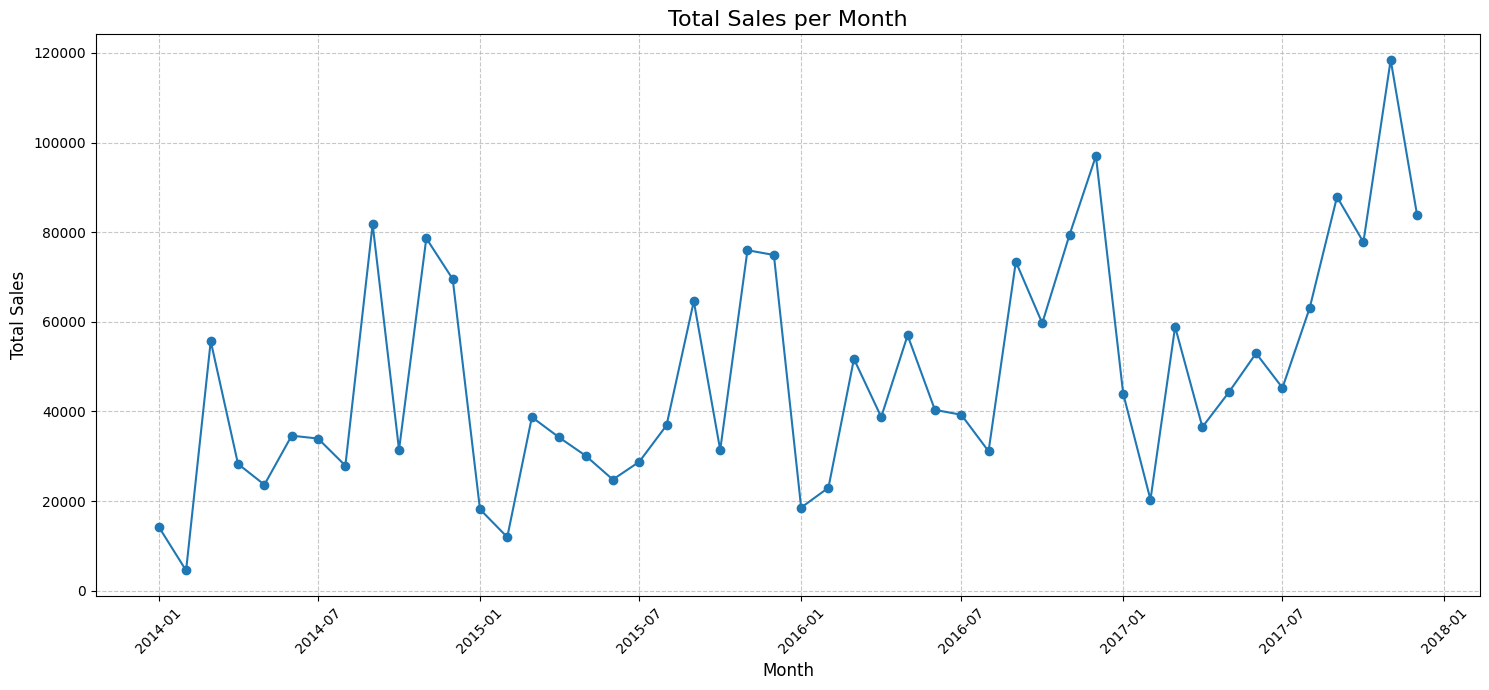

In [ ]:
import matplotlib.pyplot as plt

# Re-run the query to get monthly sales data
q_monthly_sales = """
SELECT
    strftime('%Y-%m', "Order Date") AS Month,
    ROUND(SUM(Sales),2) AS Total_Sales
FROM store
GROUP BY Month
ORDER BY Month;
"""
monthly_sales_df = pd.read_sql(q_monthly_sales, conn2)

# Convert Month to datetime for proper plotting
monthly_sales_df['Month'] = pd.to_datetime(monthly_sales_df['Month'])

# Create the plot
plt.figure(figsize=(15, 7))
plt.plot(monthly_sales_df['Month'], monthly_sales_df['Total_Sales'], marker='o', linestyle='-')
plt.title('Total Sales per Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
q="""
SELECT
    strftime('%Y', "Order Date") AS Year,
    ROUND(SUM(Sales),2) AS Total_Sales,
    ROUND(SUM(Profit),2) AS Total_Profit
FROM store
GROUP BY Year
ORDER BY Year;
"""
print(pd.read_sql(q,conn2))

   Year  Total_Sales  Total_Profit
0  2014     484251.0       49519.0
1  2015     470557.0       61603.0
2  2016     609252.0       81789.0
3  2017     733280.0       93429.0


Overall profit increases year by year but we expected more from 2017

In [ ]:
q="""
SELECT
    Category,"Sub-Category",
    ROUND(SUM(Profit),2) AS Total_Profit,
    ROUND(SUM(Sales),2) AS Total_Sales
FROM store
GROUP BY Category,"Sub-Category"
ORDER BY Total_Profit DESC;
"""
print(pd.read_sql(q,conn2))

           Category Sub-Category  Total_Profit  Total_Sales
0        Technology      Copiers       55618.0     149530.0
1        Technology       Phones       44490.0     330047.0
2        Technology  Accessories       41928.0     167400.0
3   Office Supplies        Paper       34053.0      78475.0
4   Office Supplies      Binders       30200.0     203425.0
5         Furniture       Chairs       26586.0     328453.0
6   Office Supplies      Storage       21280.0     223860.0
7   Office Supplies   Appliances       18132.0     107537.0
8         Furniture  Furnishings       13070.0      91704.0
9   Office Supplies    Envelopes        6956.0      16477.0
10  Office Supplies          Art        6529.0      27136.0
11  Office Supplies       Labels        5558.0      12505.0
12       Technology     Machines        3387.0     189242.0
13  Office Supplies    Fasteners         952.0       3024.0
14  Office Supplies     Supplies       -1187.0      46679.0
15        Furniture    Bookcases       -

In [ ]:
q="""
select *
from(
SELECT state, City,
    ROUND(AVG((Profit / Sales) * 100),2) AS Avg_Profit_Margin
FROM store
group by State, City
) t
order by Avg_profit_margin
limit 20;
"""
print(pd.read_sql(q,conn2))

       state             City  Avg_Profit_Margin
0      Texas          Abilene            -400.00
1   Illinois       Romeoville            -166.67
2      Texas    Missouri City            -166.67
3   Illinois         Danville            -160.47
4      Texas        Deer Park            -142.86
5   Colorado        Littleton            -137.50
6      Texas            Bryan            -121.29
7   Illinois        Champaign            -119.74
8      Texas            Tyler            -118.93
9   Illinois        Frankfort            -108.66
10  Illinois           Oswego            -106.44
11     Texas         La Porte            -102.68
12     Texas  College Station             -82.29
13  Illinois           Peoria             -81.57
14     Texas             Waco             -80.07
15  Illinois         Rockford             -73.05
16     Texas       San Angelo             -67.43
17   Florida     Ormond Beach             -66.67
18     Texas         Mesquite             -66.51
19  Illinois        

In [ ]:
# States_Sales_Rank, State_profit_Rank,
# City_sales_Rank, City_profit_rank,
# Customer_sales_rank, Customer_profit_rank
# Product_sales_rank, Product_Profit_rank
# State_Flag, City_flag, Customer_flag, Product_flag,
# tot_flag
df3=df2.copy()

In [ ]:
df3["State_Sales_Rank"] =df3.groupby("State")["Sales"].transform("sum").rank(ascending=False, method="dense")
df3["State_Profit_Rank"] =df3.groupby("State")["Profit"].transform("sum").rank(ascending=False, method="dense")
df3["City_Sales_Rank"] =df3.groupby("City")["Sales"].transform("sum").rank(ascending=False, method="dense")
df3["City_Profit_Rank"] =df3.groupby("City")["Profit"].transform("sum").rank(ascending=False, method="dense")
df3["Customer_Sales_Rank"] =df3.groupby("Customer ID")["Sales"].transform("sum").rank(ascending=False, method="dense")
df3["Customer_Profit_Rank"] =df3.groupby("Customer ID")["Profit"].transform("sum").rank(ascending=False, method="dense")
df3["Product_Sales_Rank"] =df3.groupby("Product ID")["Sales"].transform("sum").rank(ascending=False, method="dense")
df3["Product_Profit_Rank"] =df3.groupby("Product ID")["Profit"].transform("sum").rank(ascending=False, method="dense")

In [ ]:
df3.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Profit,Shipping_days,State_Sales_Rank,State_Profit_Rank,City_Sales_Rank,City_Profit_Rank,Customer_Sales_Rank,Customer_Profit_Rank,Product_Sales_Rank,Product_Profit_Rank
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42.0,3,14.0,8.0,23.0,17.0,566.0,372.0,417.0,526.0
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,220.0,3,14.0,8.0,23.0,17.0,566.0,372.0,29.0,27.0
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,7.0,4,1.0,1.0,2.0,2.0,571.0,575.0,895.0,420.0
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,-383.0,7,6.0,41.0,81.0,333.0,330.0,513.0,58.0,629.0
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,3.0,7,6.0,41.0,81.0,333.0,330.0,513.0,770.0,420.0


In [ ]:
conn3=sqlite3.connect("Store.db")
df3.to_sql("store", conn3,if_exists="replace")

9994

In [ ]:
q="""
select count(distinct "Product ID") as tot_products
from store;
"""
print(pd.read_sql(q,conn3))

   tot_products
0          1862


In [ ]:
# Initialize the columns
df3["State_Flag"] = 0
df3["City_Flag"] = 0
df3["Customer_Flag"] = 0
df3["Product_Flag"] = 0
df3["State_Rank_diff"] = 0
df3["City_Rank_diff"] = 0
df3["Customer_Rank_diff"] = 0
df3["Product_Rank_diff"] = 0

for i in df3.index:
    # Calculate differences
    df3.loc[i, "State_Rank_diff"] = df3.loc[i, "State_Sales_Rank"] - df3.loc[i, "State_Profit_Rank"]
    df3.loc[i, "City_Rank_diff"] = df3.loc[i, "City_Sales_Rank"] - df3.loc[i, "City_Profit_Rank"]
    df3.loc[i, "Customer_Rank_diff"] = df3.loc[i, "Customer_Sales_Rank"] - df3.loc[i, "Customer_Profit_Rank"]
    df3.loc[i, "Product_Rank_diff"] = df3.loc[i, "Product_Sales_Rank"] - df3.loc[i, "Product_Profit_Rank"]

    # State Flags
    if df3.loc[i, "State_Rank_diff"] < -30:
        df3.loc[i, "State_Flag"] = -1
    elif df3.loc[i, "State_Rank_diff"]  >15:
        df3.loc[i, "State_Flag"] = 1

    # City Flags
    if df3.loc[i, "City_Rank_diff"] < -290:
        df3.loc[i, "City_Flag"] = -1
    elif df3.loc[i, "City_Rank_diff"] > 300:
        df3.loc[i, "City_Flag"] = 1

    # Customer Flags
    if df3.loc[i, "Customer_Rank_diff"] < -300:
        df3.loc[i, "Customer_Flag"] = -1
    elif df3.loc[i, "Customer_Rank_diff"] > 300:
        df3.loc[i, "Customer_Flag"] = 1

    # Product Flags
    if df3.loc[i, "Product_Rank_diff"] < -400:
        df3.loc[i, "Product_Flag"] = -1
    elif df3.loc[i, "Product_Rank_diff"] > 600:
        df3.loc[i, "Product_Flag"] = 1

In [ ]:
conn4=sqlite3.connect("Store.db")
df3.to_sql("store", conn4,if_exists="replace")

9994

In [ ]:
q = """
select State, State_Flag, State_Rank_diff
from store
where State_Flag = 0 or State_Flag = -1
group by State
order by State_Rank_diff
limit 10;
"""
print(pd.read_sql(q, conn4))

            State  State_Flag  State_Rank_diff
0           Texas          -1              -46
1    Pennsylvania          -1              -42
2            Ohio          -1              -40
3        Illinois          -1              -39
4         Florida          -1              -35
5  North Carolina          -1              -34
6         Arizona           0              -26
7        Colorado           0              -26
8       Tennessee           0              -24
9          Oregon           0              -12


dabo is a list of states which have jumped the highest

In [ ]:
q = """
select City, City_Flag, City_Rank_diff
from store
where City_Flag = 1 or City_Flag = -1
group by City
order by City_Rank_diff;
"""
print(pd.read_sql(q, conn4))

            City  City_Flag  City_Rank_diff
0   Philadelphia         -1            -386
1        Houston         -1            -384
2        Chicago         -1            -380
3   Jacksonville         -1            -373
4    San Antonio         -1            -372
5     Burlington         -1            -368
6         Dallas         -1            -365
7         Aurora         -1            -352
8      Lancaster         -1            -352
9     Louisville         -1            -351
10       Phoenix         -1            -350
11         Miami         -1            -334
12       Concord         -1            -333
13     Charlotte         -1            -332
14        Denver         -1            -317
15       Memphis         -1            -314
16     Cleveland         -1            -312
17     Nashville         -1            -306
18    Round Rock         -1            -295


above are the list of cities which have jumped the highest

In [ ]:
q="""
select "Customer Name", Customer_Rank_diff
from store
where Customer_Flag = 1 or Customer_Flag = -1
group by "Customer ID"
order by Customer_Rank_diff
limit 20
"""
print(pd.read_sql(q, conn4))

         Customer Name  Customer_Rank_diff
0          Sean Miller                -603
1         Becky Martin                -588
2       Grant Thornton                -588
3     Natalie Fritzler                -570
4         Sean Braxton                -568
5         Peter Fuller                -557
6     Zuschuss Carroll                -557
7          Joseph Holt                -544
8         Joseph Airdo                -527
9        Cindy Stewart                -524
10      Christine Phan                -518
11     Victoria Wilson                -517
12        Tom Prescott                -491
13          Ross Baird                -488
14          Alex Avila                -477
15     Tracy Blumstein                -469
16    Stefania Perrino                -456
17  Stewart Carmichael                -441
18         Luke Foster                -431
19       Kelly Lampkin                -419


In [ ]:
# Investigate top 10 customer which jumped the most

In [ ]:
q="""
select "Sub-Category","Product Name", Product_Rank_diff
from store
where Product_Flag = 1 or Product_Flag = -1
group by "Product ID"
order by Product_Rank_diff
limit 20
"""
print(pd.read_sql(q, conn4))

   Sub-Category                                       Product Name  \
0      Machines  Cisco TelePresence System EX90 Videoconferenci...   
1      Machines          Lexmark MX611dhe Monochrome Laser Printer   
2       Binders          GBC DocuBind P400 Electric Binding System   
3      Supplies  Martin Yale Chadless Opener Electric Letter Op...   
4      Machines          Cubify CubeX 3D Printer Double Head Print   
5        Tables  Chromcraft Bull-Nose Wood Oval Conference Tabl...   
6        Tables  Bush Advantage Collection Racetrack Conference...   
7     Bookcases  Riverside Palais Royal Lawyers Bookcase, Royal...   
8      Machines          Cubify CubeX 3D Printer Triple Head Print   
9       Storage                        Tennsco Single-Tier Lockers   
10     Supplies        High Speed Automatic Electric Letter Opener   
11       Tables                       Balt Solid Wood Round Tables   
12       Tables                Bevis Oval Conference Table, Walnut   
13       Tables     

In [ ]:
# Investigate top 20 products which have jumped the most

In [ ]:
monthly_sales = (df3.groupby(df3["Order Date"].dt.to_period("M"))["Sales"].sum().reset_index())
monthly_sales["Order Date"] = monthly_sales["Order Date"].astype(str)
monthly_sales.head()

,Order Date,Sales
0,2014-01,14238.0
1,2014-02,4518.0
2,2014-03,55688.0
3,2014-04,28294.0
4,2014-05,23648.0


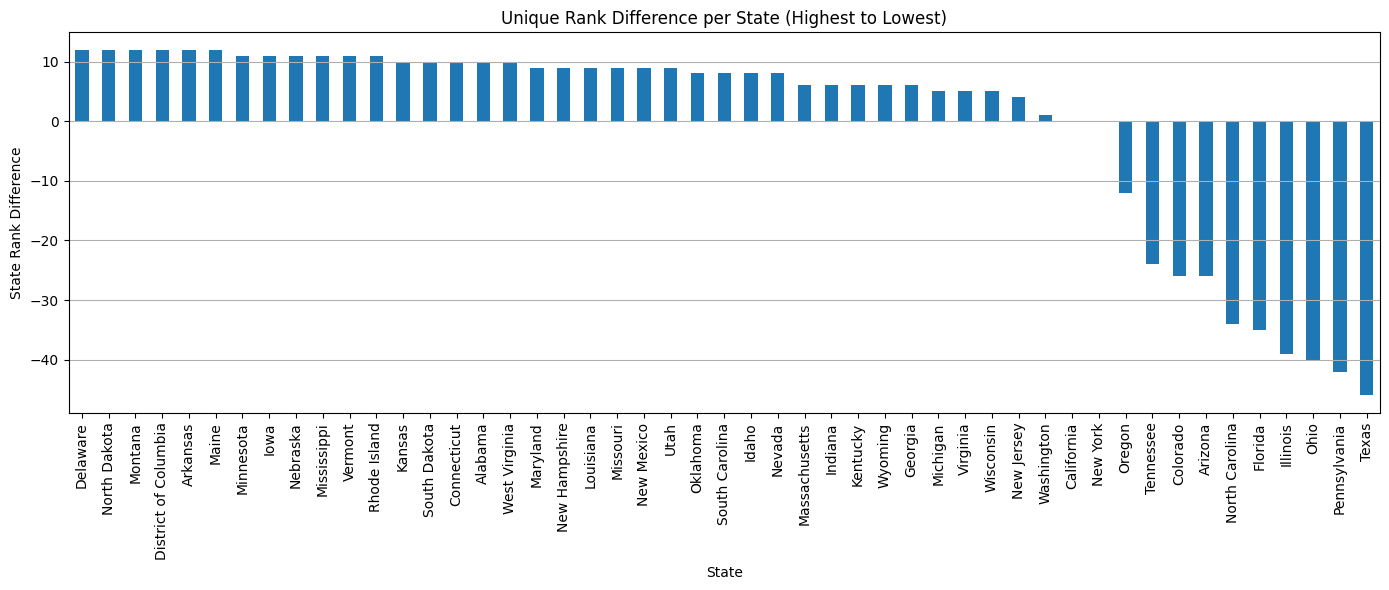

In [ ]:
ordered_state_diffs = (df3.drop_duplicates(subset=["State"]).set_index("State")["State_Rank_diff"].sort_values(ascending=False))
plt.figure(figsize=(14, 6))
ordered_state_diffs.plot(kind="bar")
plt.title("Unique Rank Difference per State (Highest to Lowest)")
plt.xlabel("State")
plt.ylabel("State Rank Difference")
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

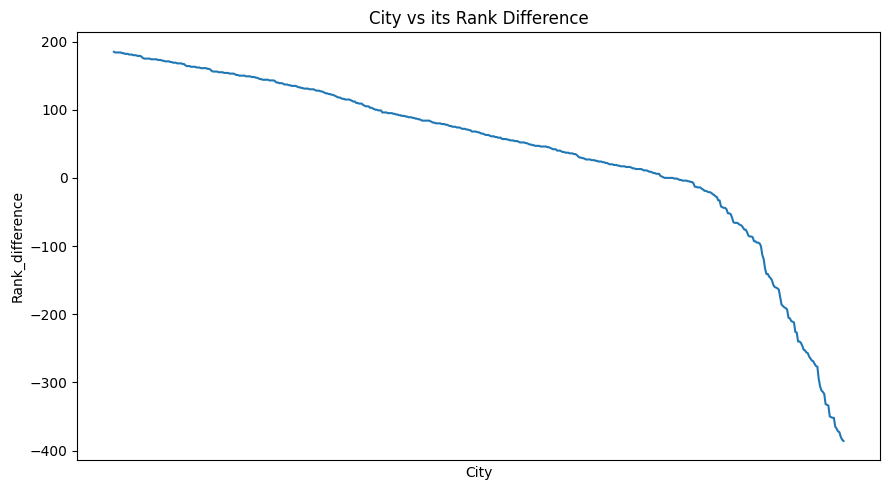

In [ ]:
city_rank= df3.drop_duplicates(subset=["City"]).set_index("City")["City_Rank_diff"].sort_values(ascending=False)
plt.figure(figsize=(9,5))
city_rank.plot(kind='line')
plt.title("City vs its Rank Difference")
plt.xlabel("City")
plt.ylabel("Rank_difference")
plt.xticks([])
plt.tight_layout()
plt.show()

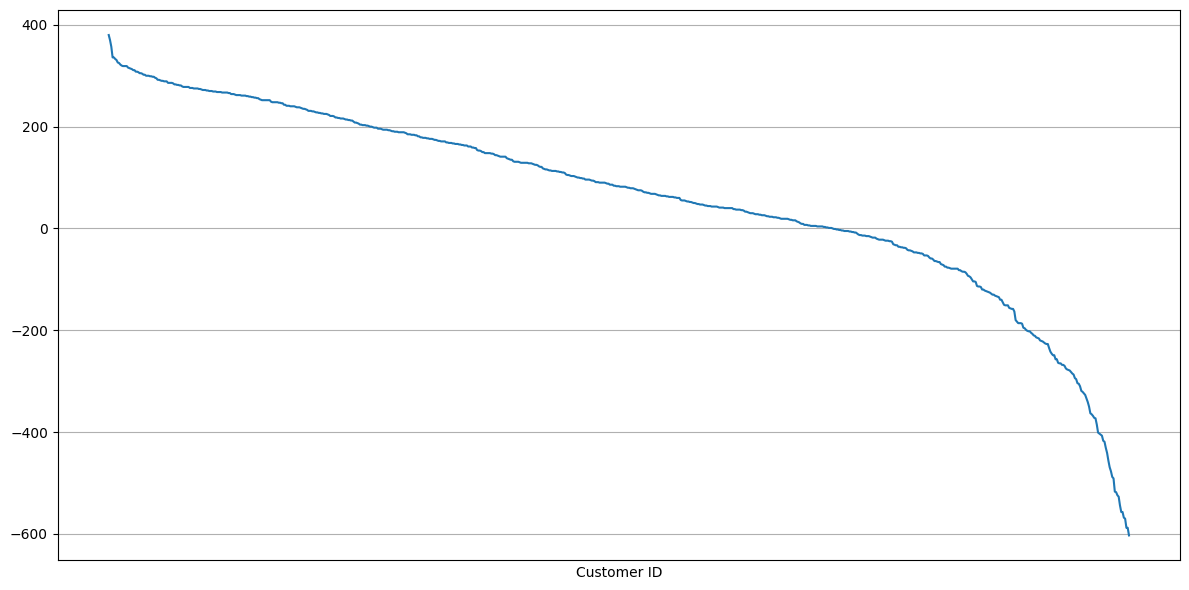

In [ ]:
customer_diffs = (df3.drop_duplicates(subset=["Customer ID"]).set_index("Customer ID")["Customer_Rank_diff"].sort_values(ascending=False))
plt.figure(figsize=(12, 6))
customer_diffs.plot(kind="line")
plt.xticks([])
plt.grid(axis='y')
plt.tight_layout()
plt.show()

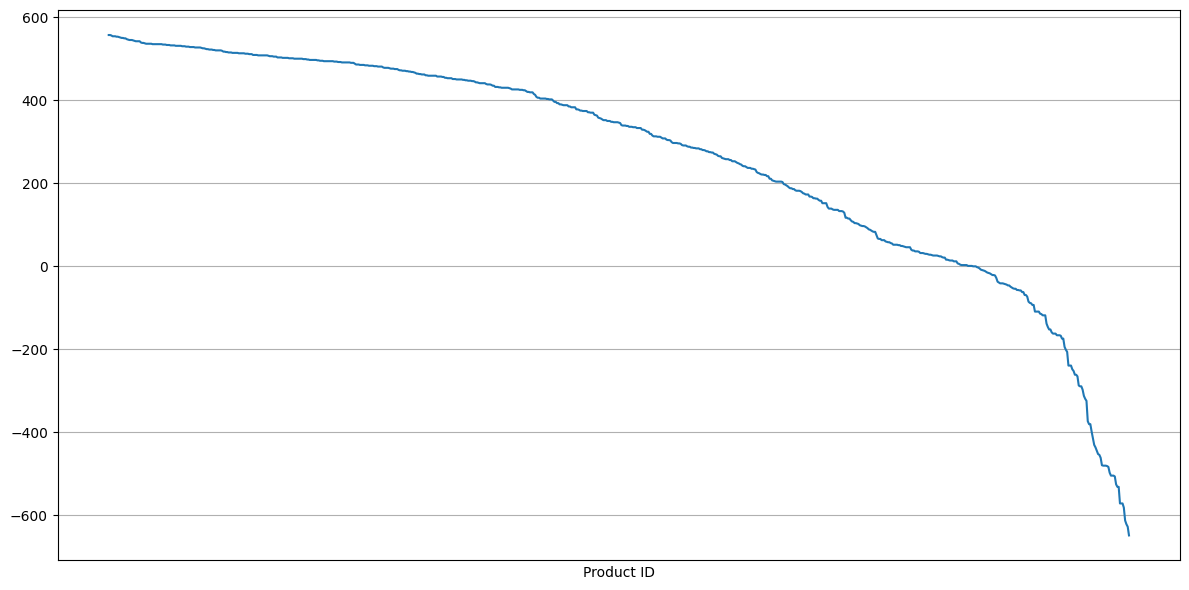

In [ ]:
Prod_Rank=df3.drop_duplicates("Customer ID").set_index("Product ID")["Product_Rank_diff"].sort_values(ascending=False)
plt.figure(figsize=(12,6))
Prod_Rank.plot(kind='line')
plt.xticks([])
plt.grid(axis='y')
plt.tight_layout()
plt.show()

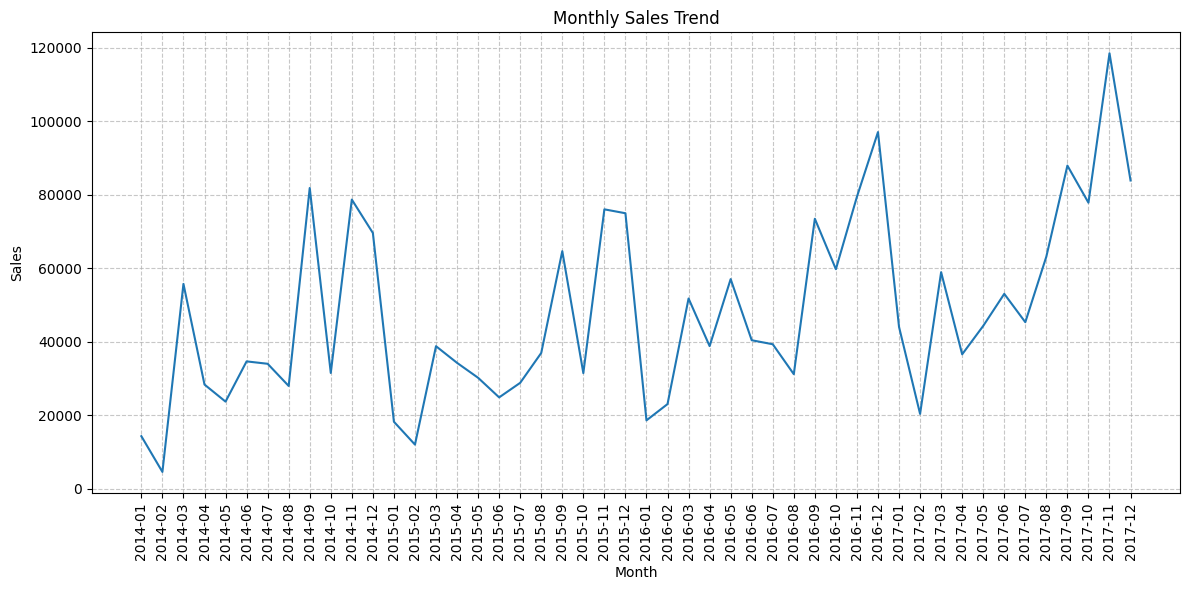

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"]
)
plt.grid(True, linestyle='--', alpha=0.7)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
# Sales peak during Sept
# Sales dips during Feb
# Over sales increases year by year
# We can use 10% discount when the sales are on peak and use 50% discount when the sales are dipping

In [ ]:
monthly_sales = (
    df3.groupby([df3["Order Date"].dt.to_period('M'),"Category"])["Sales"]
      .sum()
      .reset_index()
)
monthly_sales["Order Date"] = monthly_sales["Order Date"].astype(str)
monthly_sales.head()

,Order Date,Category,Sales
0,2014-01,Furniture,6243.0
1,2014-01,Office Supplies,4852.0
2,2014-01,Technology,3143.0
3,2014-02,Furniture,1840.0
4,2014-02,Office Supplies,1070.0


In [ ]:
monthly_profit = (
    df3.groupby([df3["Order Date"].dt.to_period('M'),"Category"])["Profit"]
      .sum()
      .reset_index()
)
monthly_profit["Order Date"] = monthly_profit["Order Date"].astype(str)
monthly_profit.head()

,Order Date,Category,Profit
0,2014-01,Furniture,804.0
1,2014-01,Office Supplies,785.0
2,2014-01,Technology,857.0
3,2014-02,Furniture,121.0
4,2014-02,Office Supplies,173.0


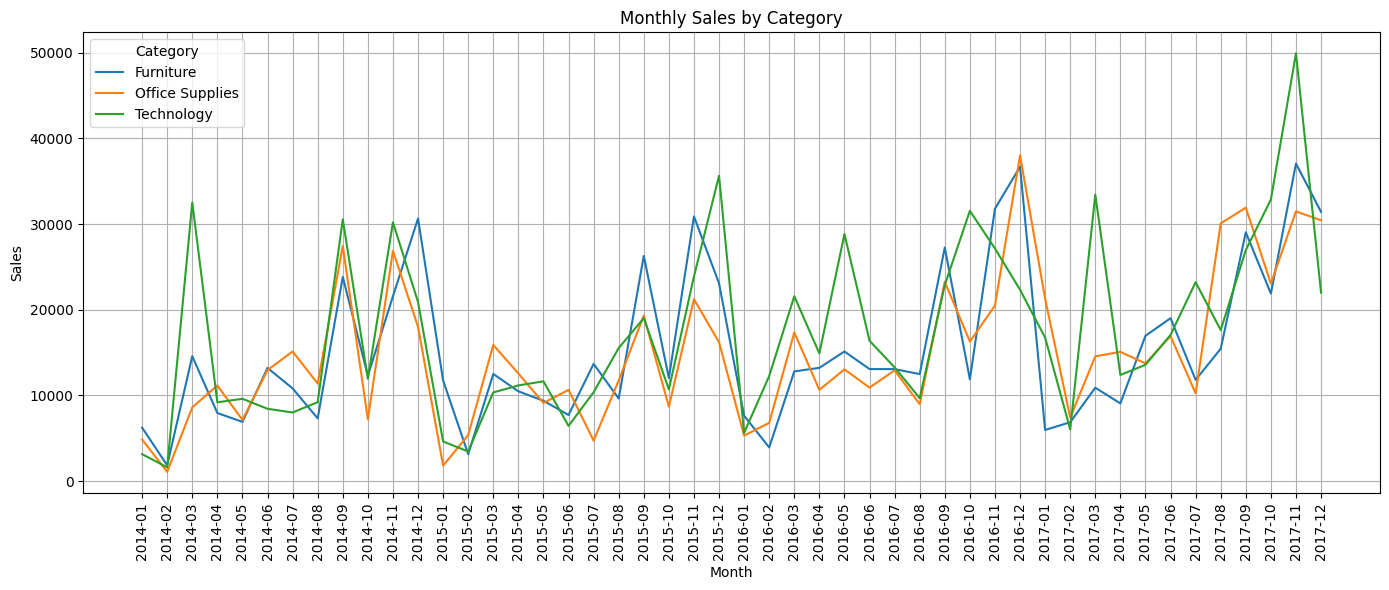

In [ ]:
pivot = monthly_sales.pivot(
    index="Order Date",
    columns="Category",
    values="Sales"
)

pivot.plot(figsize=(14,6))

plt.title("Monthly Sales by Category")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(range(len(pivot.index)), pivot.index, rotation=90)
plt.tight_layout()
plt.grid(True)
plt.show()

only technology peaks at march whereas fur and off behaves normally

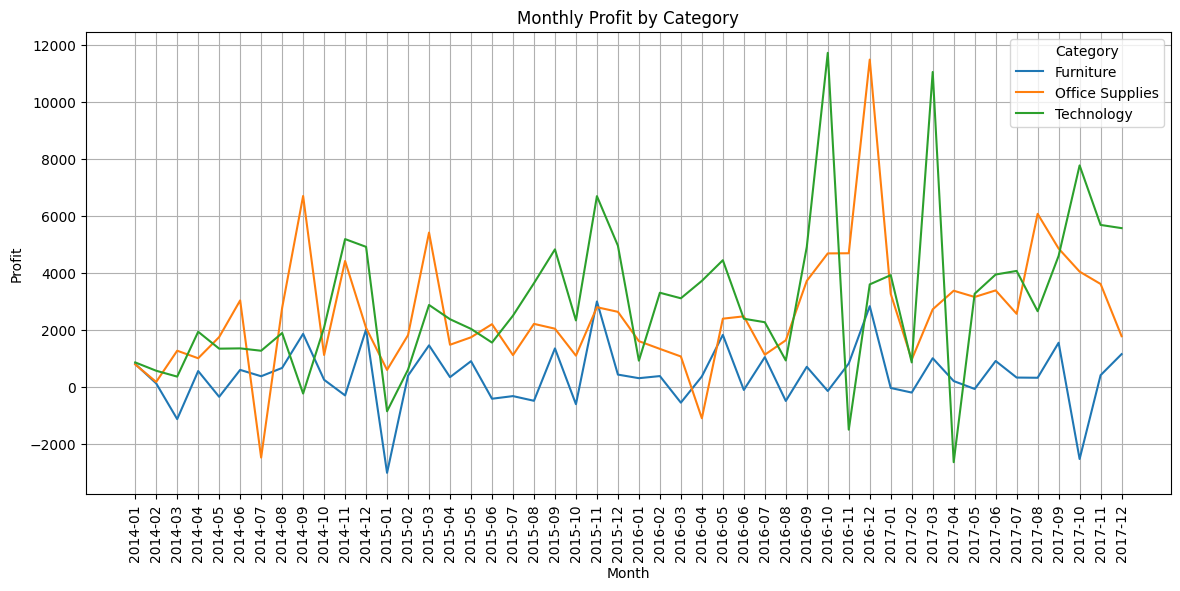

In [ ]:
pivot = monthly_profit.pivot(
    index="Order Date",
    columns="Category",
    values="Profit"
)

pivot.plot(figsize=(14,6))

plt.title("Monthly Profit by Category")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.xticks(range(len(pivot.index)), pivot.index, rotation=90)
plt.grid(True)
plt.show()

even though sales values were good in march for technology the profit show no effect except for the march of 2017
furniture tips significantly at January 2015 and 10th of 2017

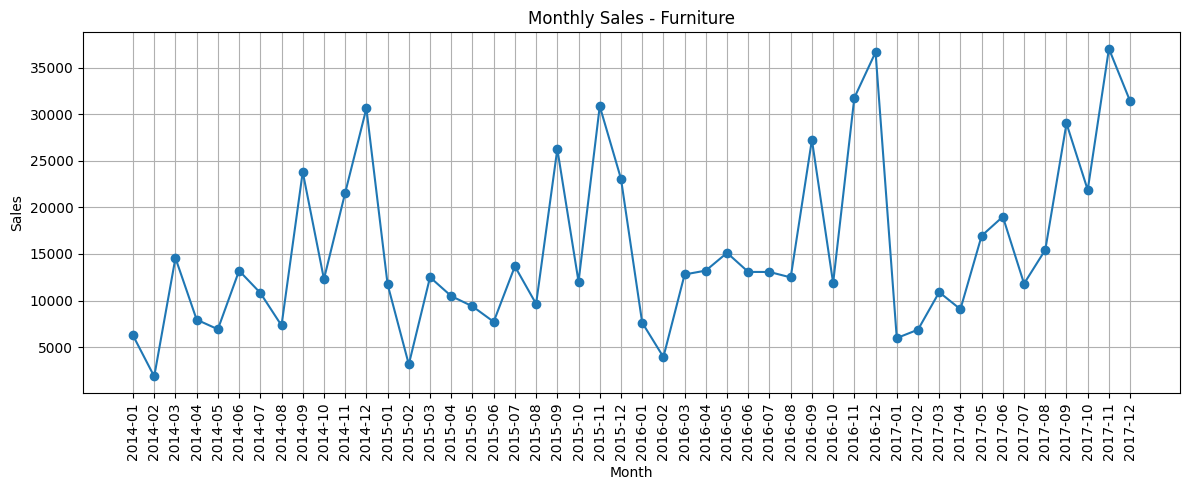

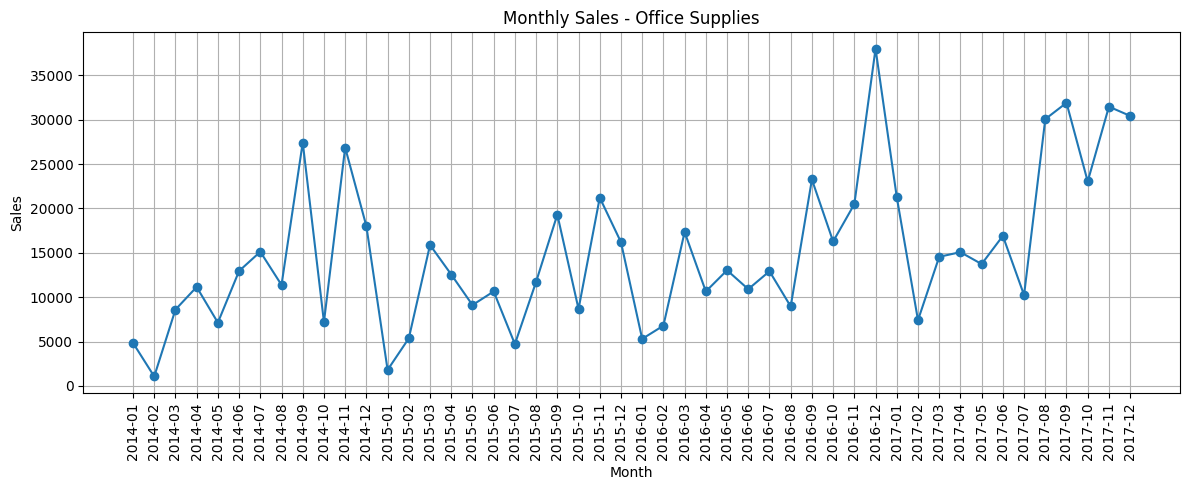

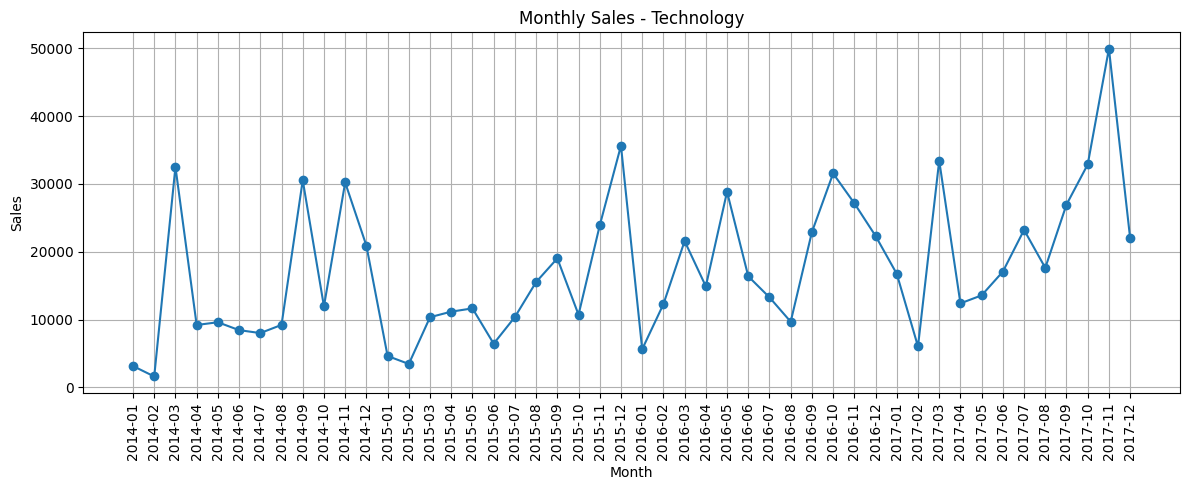

In [ ]:
categories = monthly_sales["Category"].unique()

for category in categories:
    temp = monthly_sales[monthly_sales["Category"] == category]

    plt.figure(figsize=(12,5))
    plt.plot(temp["Order Date"], temp["Sales"], marker='o')
    plt.title(f"Monthly Sales - {category}")
    plt.xlabel("Month")
    plt.ylabel("Sales")
    plt.xticks(rotation=90)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

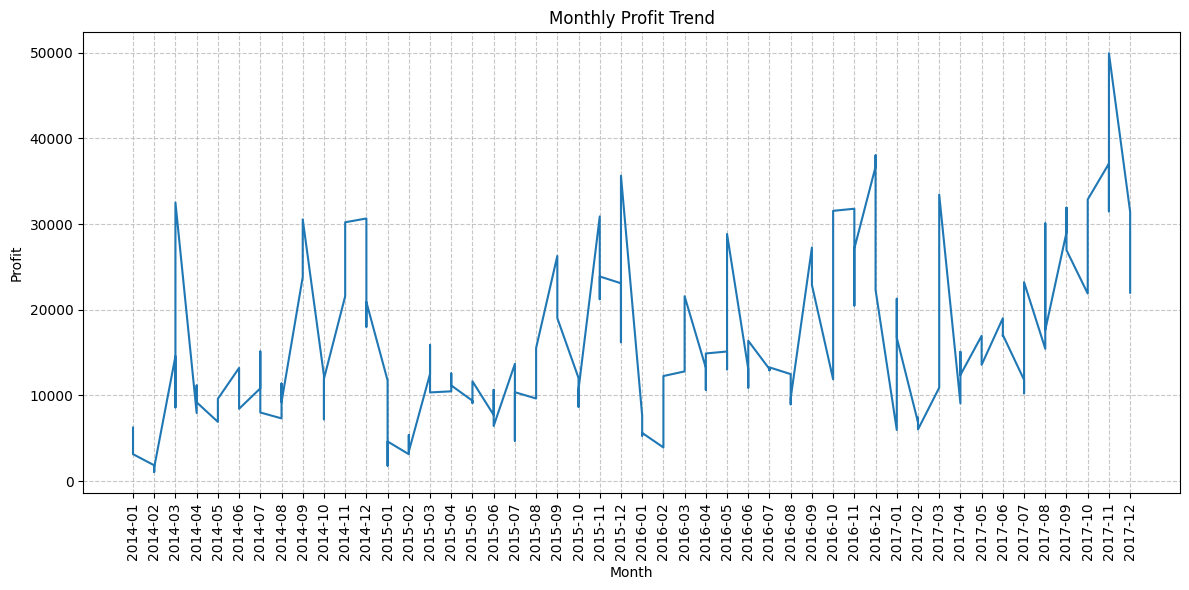

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"]
)
plt.grid(True, linestyle='--', alpha=0.7)
plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
# something happend on 2015-01
# 2016 peaks performs better than 2017 peaks

In [ ]:
a="""
select "Customer Name","Product Name", Category, Sales, Discount, Profit,"Order Date"
from store
where "Order Date" >= '2015-01-01' and "Order Date" <= '2015-01-30' and Category = 'Furniture'
order by "Profit";
"""
display(pd.read_sql(a, conn3))

,Customer Name,Product Name,Category,Sales,Discount,Profit,Order Date
0,Joseph Holt,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,4298.0,40.0,-1862.0,2015-01-28 00:00:00
1,Amy Hunt,O'Sullivan Living Dimensions 5-Shelf Bookcases,Furniture,1352.0,32.0,-438.0,2015-01-03 00:00:00
2,Michael Moore,Bush Advantage Collection Racetrack Conference...,Furniture,1018.0,40.0,-373.0,2015-01-10 00:00:00
3,Joni Sundaresam,Eldon ClusterMat Chair Mat with Cordless Antis...,Furniture,255.0,60.0,-312.0,2015-01-17 00:00:00
4,Victoria Wilson,O'Sullivan 2-Door Barrister Bookcase in Odessa...,Furniture,452.0,50.0,-244.0,2015-01-02 00:00:00
5,Seth Vernon,High-Back Leather Manager's Chair,Furniture,182.0,30.0,-55.0,2015-01-27 00:00:00
6,Paul MacIntyre,Bevis Round Conference Table Top & Single Colu...,Furniture,102.0,30.0,-13.0,2015-01-19 00:00:00
7,Paul MacIntyre,Harbour Creations 67200 Series Stacking Chairs,Furniture,199.0,30.0,-9.0,2015-01-19 00:00:00
8,Steven Roelle,Global Deluxe Steno Chair,Furniture,62.0,20.0,-7.0,2015-01-05 00:00:00
9,Sean Christensen,HON 5400 Series Task Chairs for Big and Tall,Furniture,2804.0,20.0,0.0,2015-01-27 00:00:00


In [ ]:
a="""
select "Customer Name","Product Name", Category, Sales, Discount, Profit,"Order Date"
from store
where "Order Date" >= '2014-07-01' and "Order Date" <= '2014-07-30' and Category = 'Office Supplies'
order by "Profit";
"""
display(pd.read_sql(a, conn3))

,Customer Name,Product Name,Category,Sales,Discount,Profit,Order Date
0,Luke Foster,GBC DocuBind P400 Electric Binding System,Office Supplies,2178.0,80.0,-3702.0,2014-07-26 00:00:00
1,Arthur Wiediger,Acco D-Ring Binder w/DublLock,Office Supplies,30.0,80.0,-46.0,2014-07-14 00:00:00
2,Dan Campbell,"Gould Plastics 18-Pocket Panel Bin, 34w x 5-1/...",Office Supplies,221.0,20.0,-44.0,2014-07-05 00:00:00
3,Dan Campbell,Fellowes Bankers Box Stor/Drawer Steel Plus,Office Supplies,281.0,20.0,-35.0,2014-07-05 00:00:00
4,Carl Ludwig,"Belkin 19"" Vented Equipment Shelf, Black",Office Supplies,124.0,20.0,-29.0,2014-07-26 00:00:00
...,...,...,...,...,...,...,...
77,Naresj Patel,Eldon Mobile Mega Data Cart Mega Stackable Add...,Office Supplies,236.0,0.0,69.0,2014-07-22 00:00:00
78,Sheri Gordon,Avery 485,Office Supplies,163.0,0.0,77.0,2014-07-26 00:00:00
79,Laura Armstrong,Easy-staple paper,Office Supplies,177.0,0.0,83.0,2014-07-11 00:00:00
80,Jonathan Doherty,"Hot File 7-Pocket, Floor Stand",Office Supplies,535.0,0.0,161.0,2014-07-20 00:00:00


In [ ]:
a="""
select "Customer Name","Product Name", Category, Sales, Discount, Profit,"Order Date"
from store
where "Order Date" >= '2017-04-01' and "Order Date" <= '2017-04-30' and Category = 'Technology'
order by "Profit";
"""
display(pd.read_sql(a, conn3))

,Customer Name,Product Name,Category,Sales,Discount,Profit,Order Date
0,Sharelle Roach,Lexmark MX611dhe Monochrome Laser Printer,Technology,2550.0,70.0,-3400.0,2017-04-17 00:00:00
1,Brad Eason,Avaya 5410 Digital phone,Technology,122.0,40.0,-24.0,2017-04-20 00:00:00
2,Christopher Schild,Logitech P710e Mobile Speakerphone,Technology,618.0,20.0,-8.0,2017-04-07 00:00:00
3,Barry Französisch,Mediabridge Sport Armband iPhone 5s,Technology,24.0,20.0,-6.0,2017-04-01 00:00:00
4,Jack Lebron,Kingston Digital DataTraveler 32GB USB 2.0,Technology,27.0,20.0,-5.0,2017-04-11 00:00:00
5,Edward Becker,SanDisk Ultra 16 GB MicroSDHC Class 10 Memory ...,Technology,26.0,0.0,2.0,2017-04-16 00:00:00
6,Joni Wasserman,"Verbatim Slim CD and DVD Storage Cases, 50/Pack",Technology,12.0,0.0,3.0,2017-04-21 00:00:00
7,Linda Southworth,V7 USB Numeric Keypad,Technology,70.0,0.0,5.0,2017-04-24 00:00:00
8,Katherine Nockton,Logitech LS21 Speaker System - PC Multimedia -...,Technology,48.0,20.0,8.0,2017-04-21 00:00:00
9,Darrin Sayre,Panasonic KX - TS880B Telephone,Technology,41.0,0.0,11.0,2017-04-04 00:00:00


In [ ]:
sales_category = (
    df3.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

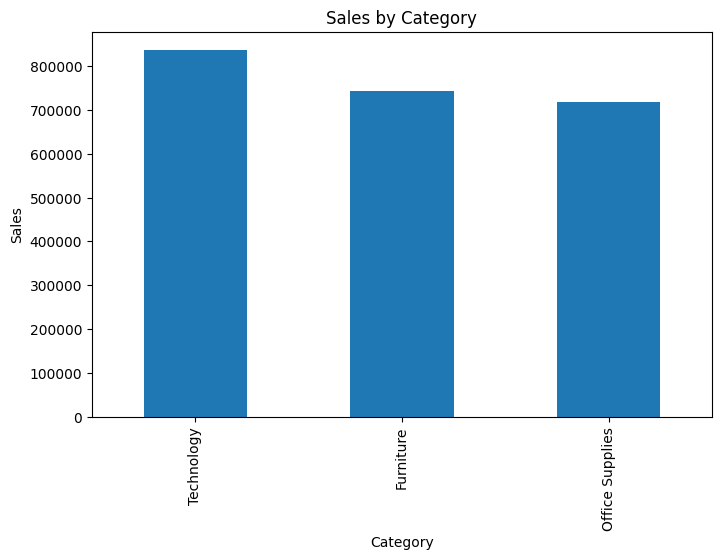

In [ ]:
sales_category.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sales by Category")
plt.ylabel("Sales")

plt.show()

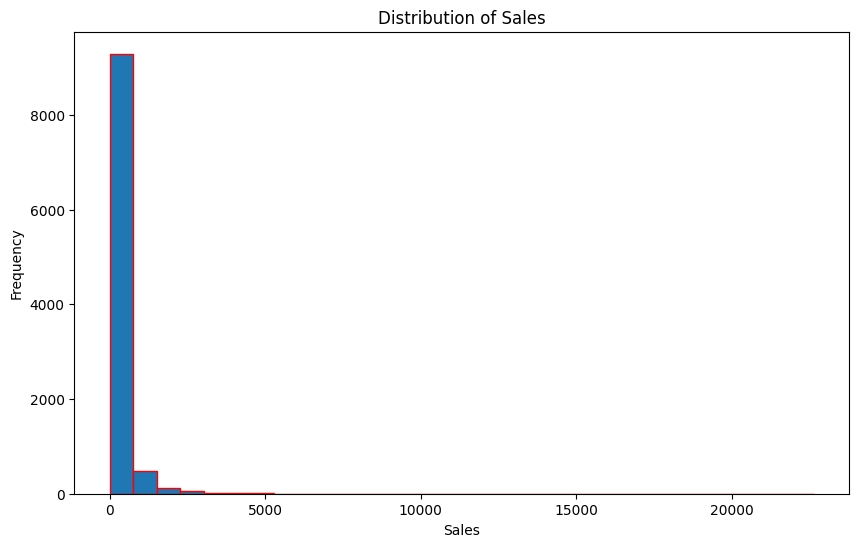

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    df3["Sales"],
    bins=30, edgecolor='red'
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

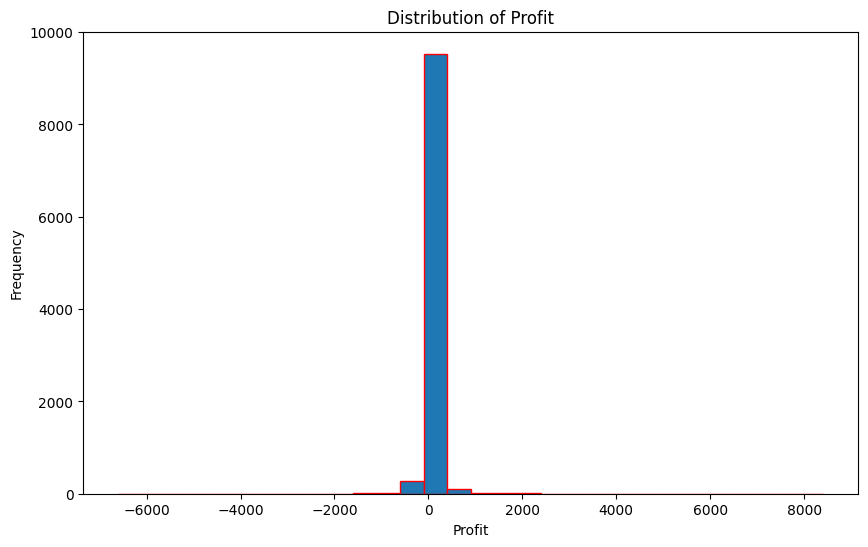

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    df3["Profit"],
    bins=30, edgecolor='red'
)

plt.title("Distribution of Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.show()

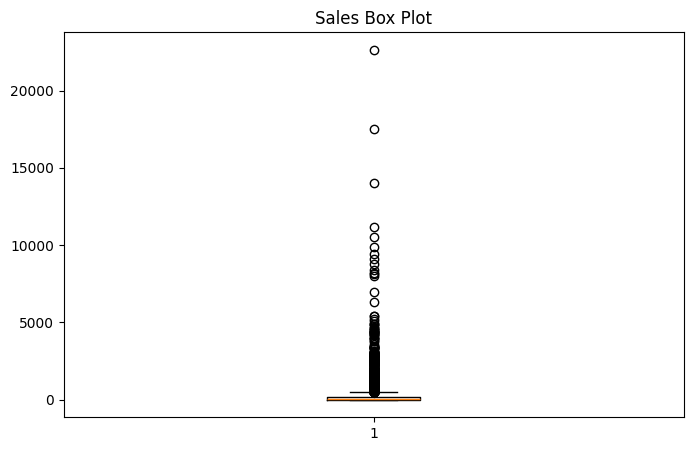

In [ ]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Sales"])

plt.title("Sales Box Plot")

plt.show()

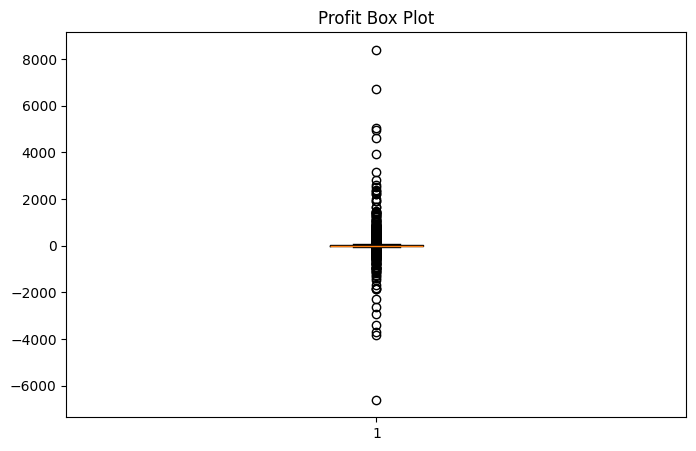

In [ ]:
plt.figure(figsize=(8,5))

plt.boxplot(df["Profit"])

plt.title("Profit Box Plot")

plt.show()

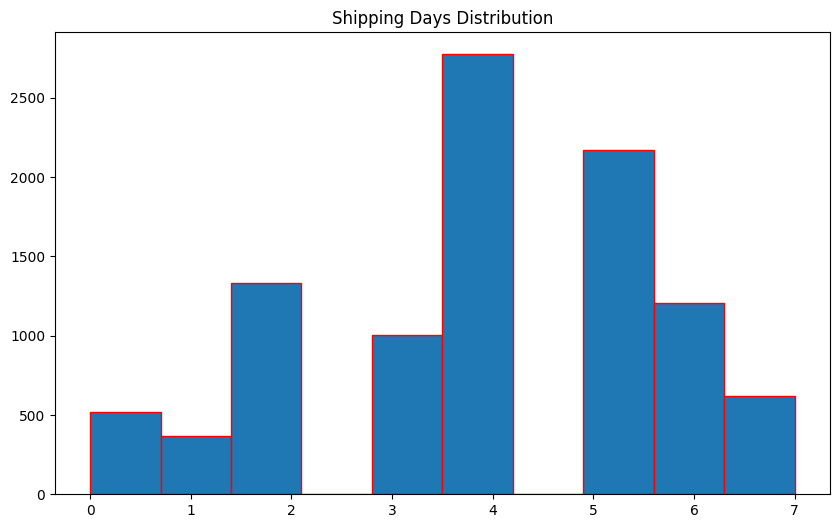

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(
    df3["Shipping_days"],
    bins=10, edgecolor = "Red"
)

plt.title("Shipping Days Distribution")

plt.show()

In [ ]:
sub = (df3.groupby("Sub-Category")[["Sales", "Profit"]].sum().sort_values(by="Profit", ascending=False))
print(sub)

                 Sales   Profit
Sub-Category                   
Copiers       149530.0  55618.0
Phones        330047.0  44490.0
Accessories   167400.0  41928.0
Paper          78475.0  34053.0
Binders       203425.0  30200.0
Chairs        328453.0  26586.0
Storage       223860.0  21280.0
Appliances    107537.0  18132.0
Furnishings    91704.0  13070.0
Envelopes      16477.0   6956.0
Art            27136.0   6529.0
Labels         12505.0   5558.0
Machines      189242.0   3387.0
Fasteners       3024.0    952.0
Supplies       46679.0  -1187.0
Bookcases     114879.0  -3479.0
Tables        206967.0 -17733.0


<Axes: xlabel='Sub-Category'>

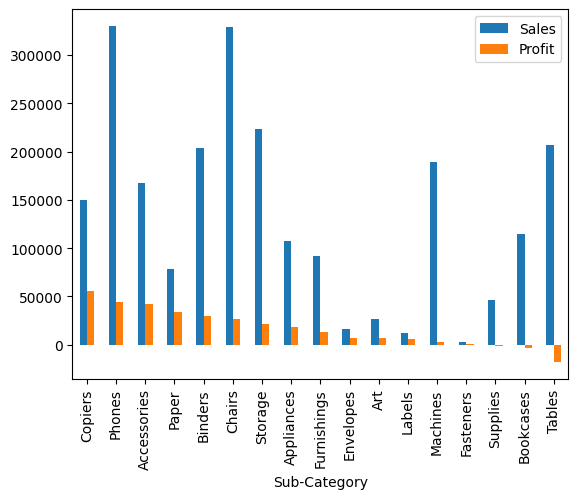

In [ ]:
sub.plot(kind='bar')

In [ ]:
# Machines, Bookcase, Tables

<Axes: xlabel='State'>

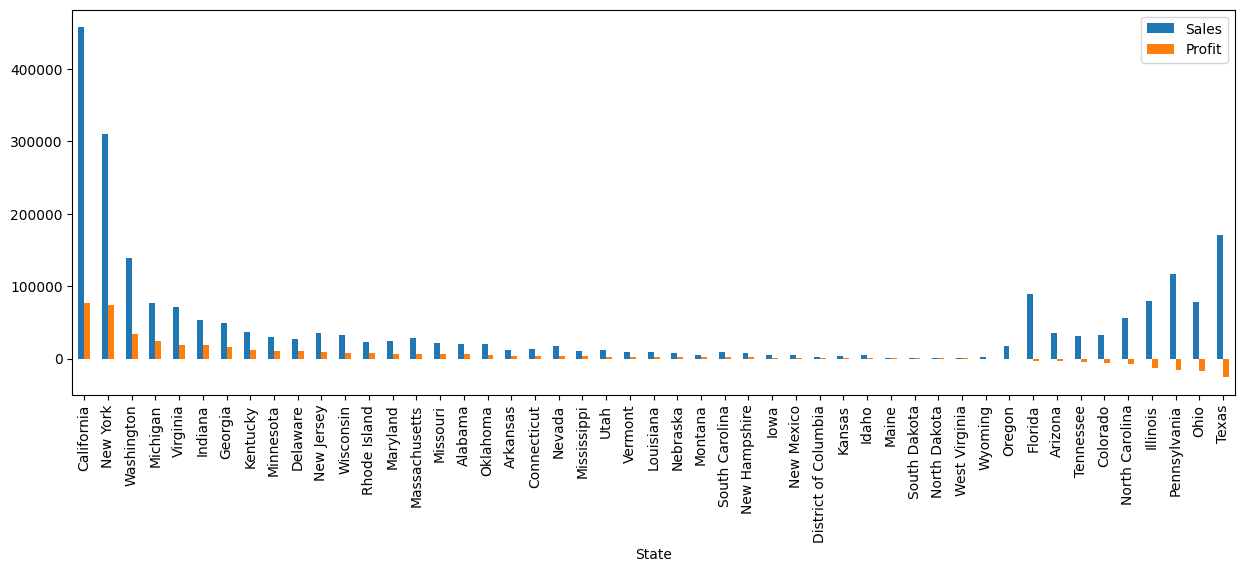

In [ ]:
state= (df3.groupby("State")[["Sales", "Profit"]].sum().sort_values(by="Profit", ascending=False))
state.plot(kind='bar',figsize=(15,5))

In [ ]:
# Investigate Florida, Illinois, Pennsylvania, Ohio, Texas

<Axes: xlabel='Region'>

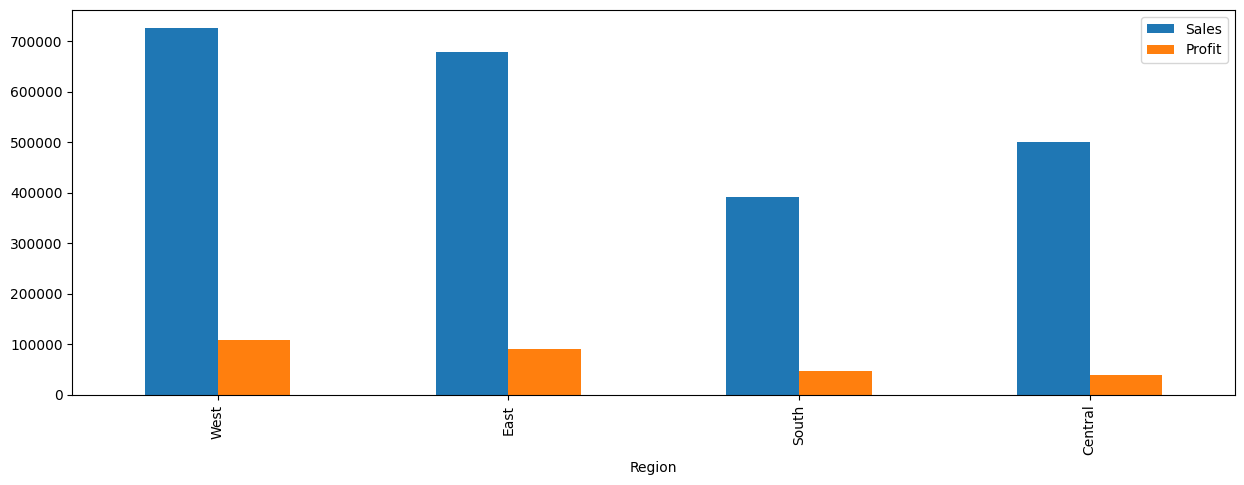

In [ ]:
Region= (df3.groupby("Region")[["Sales", "Profit"]].sum().sort_values(by="Profit", ascending=False))
Region.plot(kind='bar',figsize=(15,5))

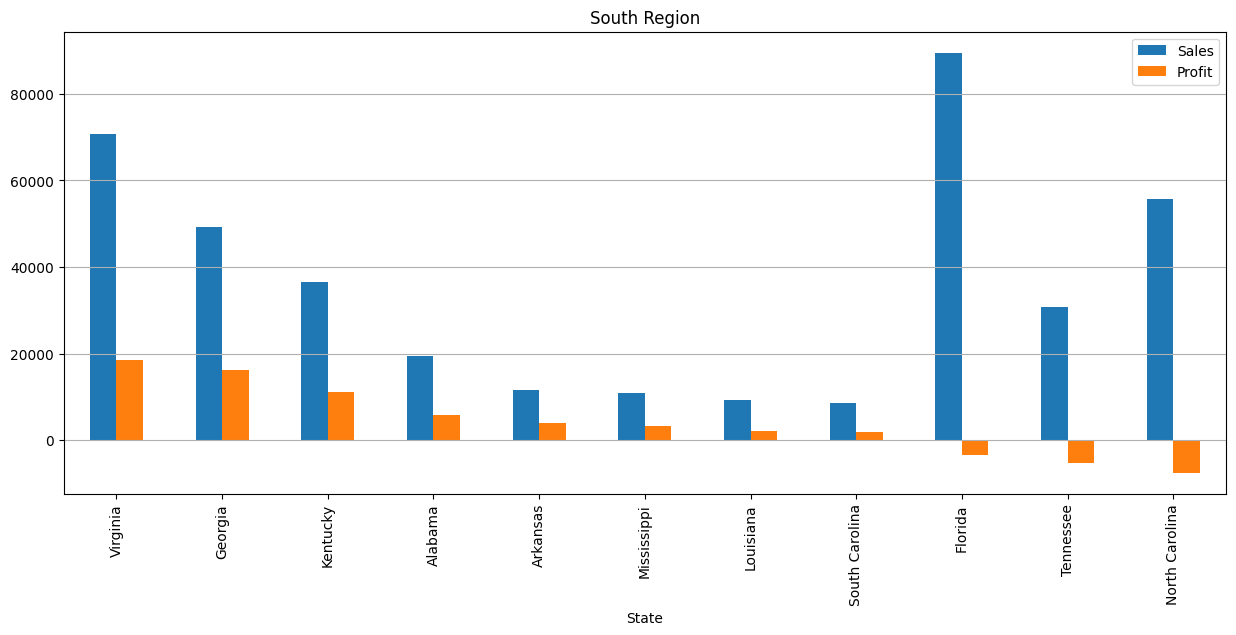

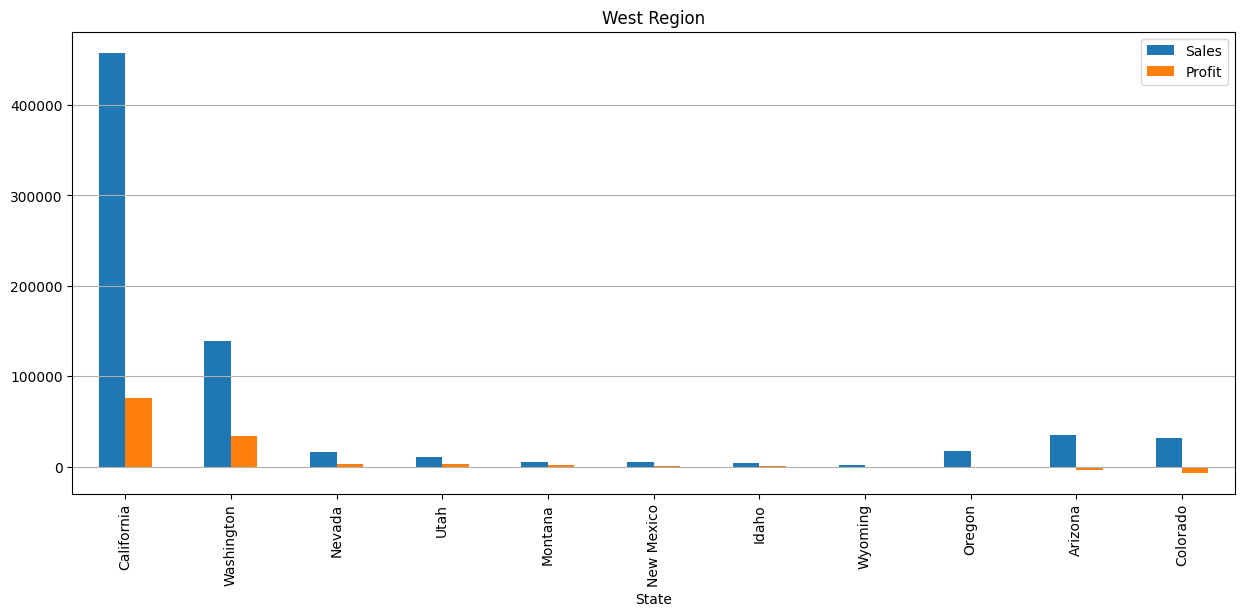

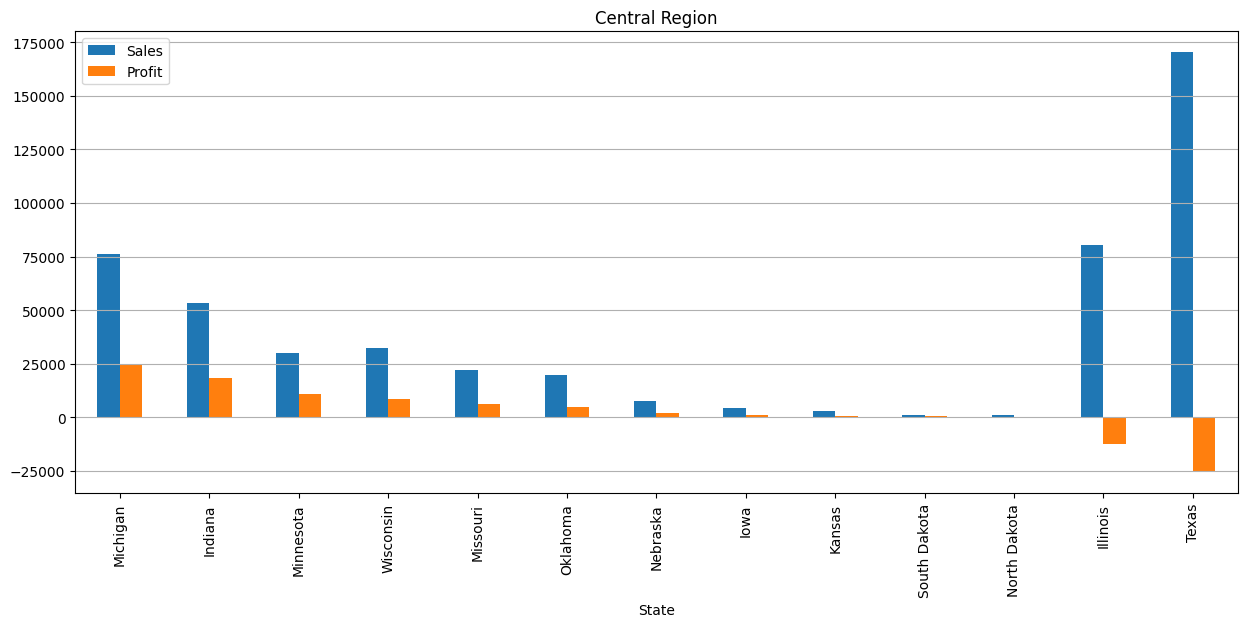

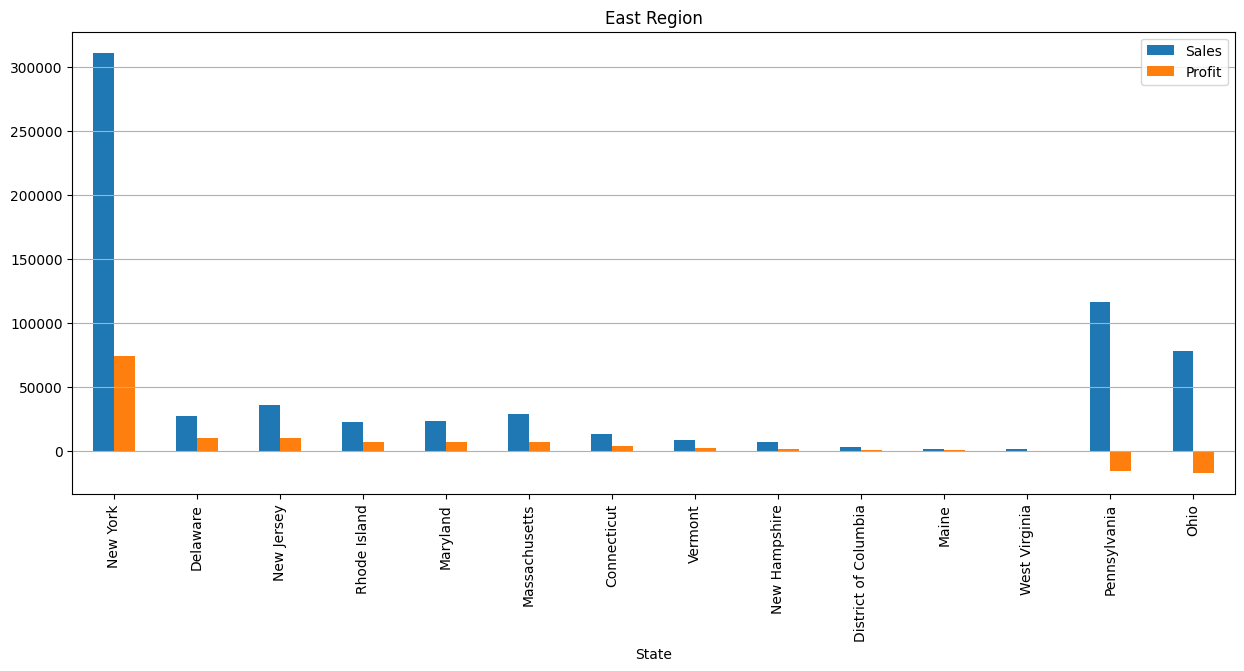

In [ ]:
regions = df3["Region"].unique()
per_region = (df3.groupby(["Region","State"])[["Sales","Profit"]].sum().sort_values(by='Profit',ascending=False).reset_index())
for region in regions:
    temp = per_region[per_region["Region"] == region]
    temp.set_index("State")[["Sales","Profit"]].plot(kind="bar",figsize=(15,6),title=f"{region} Region")
    plt.xticks(rotation=90)
    plt.grid(axis='y')
    plt.show()

In [ ]:
states_by_region = (
    df.groupby("Region")["State"]
    .unique()
)

print(states_by_region)

Region
Central    [Texas, Wisconsin, Nebraska, Illinois, Minneso...
East       [Pennsylvania, Delaware, New York, Ohio, Conne...
South      [Kentucky, Florida, North Carolina, Virginia, ...
West       [California, Washington, Utah, Arizona, Oregon...
Name: State, dtype: object


In [ ]:
def find_rank_difference(column):
    sales_rank = (df3.groupby(column)["Sales"].sum().rank(ascending=False,method="dense"))
    profit_rank = (df3.groupby(column)["Profit"].sum().rank(ascending=False,method="dense"))
    result = pd.DataFrame({"Sales Rank":sales_rank,"Profit Rank":profit_rank})
    result["Rank Difference"] = abs(result["Sales Rank"] -result["Profit Rank"])
    return result.sort_values(by="Rank Difference",ascending=False)

In [ ]:
find_rank_difference("City")

,Sales Rank,Profit Rank,Rank Difference
City,,,
Philadelphia,5.0,391.0,386.0
Houston,6.0,390.0,384.0
Chicago,7.0,387.0,380.0
Jacksonville,9.0,382.0,373.0
San Antonio,17.0,389.0,372.0
...,...,...,...
Columbus,12.0,12.0,0.0
Columbia,14.0,14.0,0.0
Seattle,3.0,3.0,0.0


In [ ]:
q = """
select City, City_Flag, City_Rank_diff
from store
where City_Flag = 1 or City_Flag = -1
group by City
order by City_Rank_diff;
"""
display(pd.read_sql(q, conn4))

,City,City_Flag,City_Rank_diff
0,Philadelphia,-1,-386
1,Houston,-1,-384
2,Chicago,-1,-380
3,Jacksonville,-1,-373
4,San Antonio,-1,-372
5,Burlington,-1,-368
6,Dallas,-1,-365
7,Aurora,-1,-352
8,Lancaster,-1,-352
9,Louisville,-1,-351


In [ ]:
find_rank_difference("Customer Name").head(20)

,Sales Rank,Profit Rank,Rank Difference
Customer Name,,,
Sean Miller,1.0,604.0,603.0
Becky Martin,13.0,601.0,588.0
Grant Thornton,22.0,610.0,588.0
Natalie Fritzler,32.0,602.0,570.0
Sean Braxton,37.0,605.0,568.0
Peter Fuller,25.0,582.0,557.0
Zuschuss Carroll,38.0,595.0,557.0
Joseph Holt,39.0,583.0,544.0
Joseph Airdo,63.0,590.0,527.0


In [ ]:
find_rank_difference("State").head(20)

,Sales Rank,Profit Rank,Rank Difference
State,,,
Texas,3.0,49.0,46.0
Pennsylvania,5.0,47.0,42.0
Ohio,8.0,48.0,40.0
Illinois,7.0,46.0,39.0
Florida,6.0,41.0,35.0
North Carolina,11.0,45.0,34.0
Colorado,18.0,44.0,26.0
Arizona,16.0,42.0,26.0
Tennessee,19.0,43.0,24.0


In [ ]:
monthly_profit = (
    df3.groupby([df3["Order Date"].dt.to_period('M'),"Category"])["Profit"]
      .sum()
      .reset_index()
)
monthly_profit["Order Date"] = monthly_profit["Order Date"].astype(str)
monthly_profit.head()

,Order Date,Category,Profit
0,2014-01,Furniture,804.0
1,2014-01,Office Supplies,785.0
2,2014-01,Technology,857.0
3,2014-02,Furniture,121.0
4,2014-02,Office Supplies,173.0


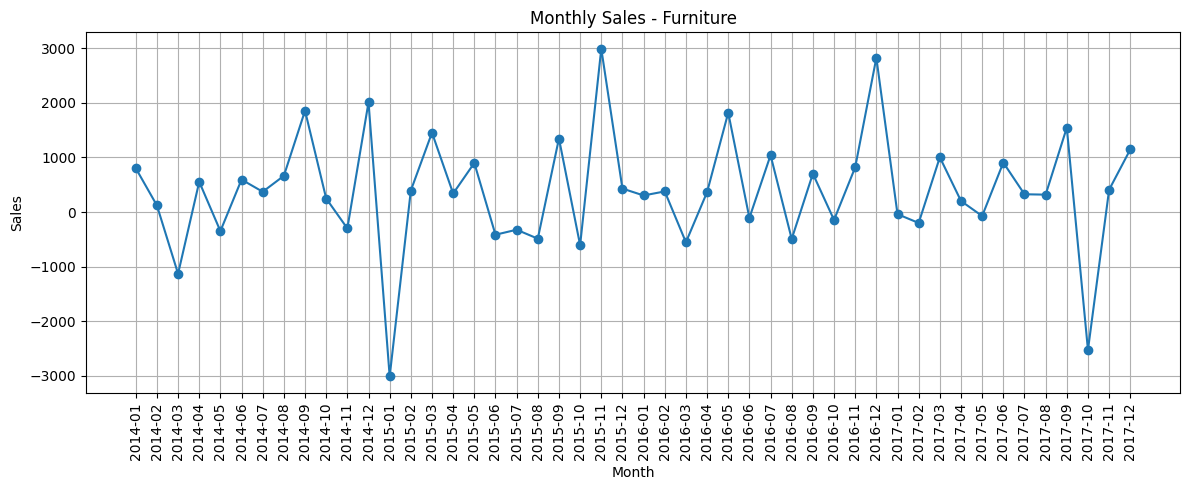

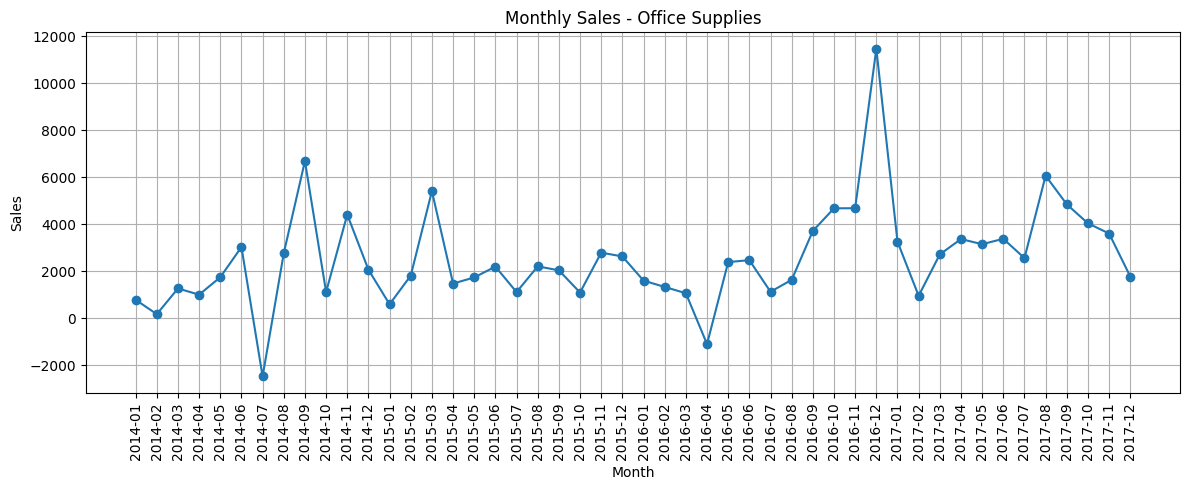

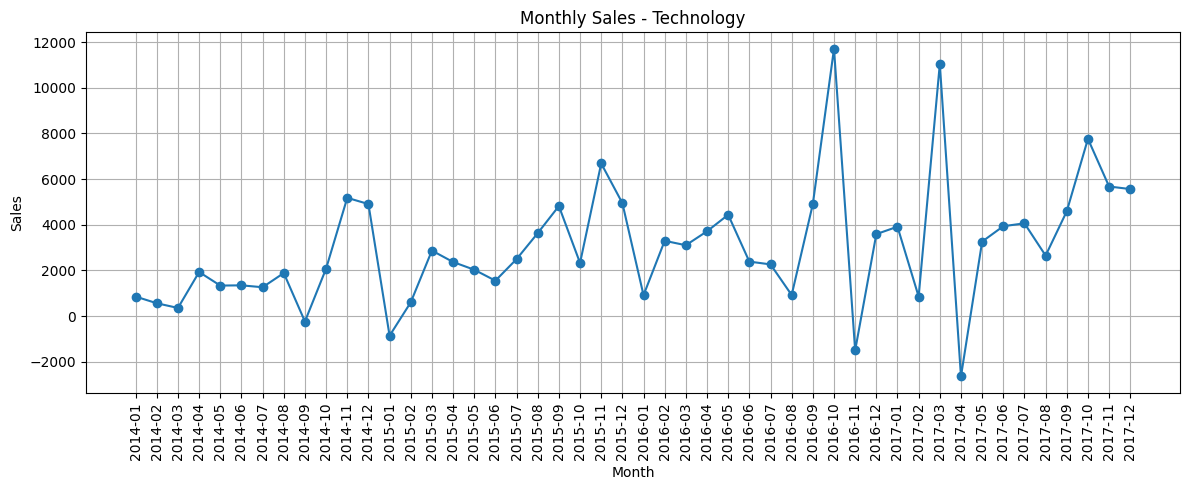

In [ ]:
categories = monthly_profit["Category"].unique()

for category in categories:
    temp = monthly_profit[monthly_profit["Category"] == category]
    plt.figure(figsize=(12,5))
    plt.plot(temp["Order Date"], temp["Profit"], marker='o')
    plt.title(f"Monthly Sales - {category}")
    plt.xlabel("Month")
    plt.ylabel("Sales")
    plt.xticks(rotation=90)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
a="""
select "Customer Name","Product Name", Category, Sales, Discount,"Sub-Category", Profit,"Order Date"
from store
where "Order Date" >= '2015-01-01' and "Order Date" <= '2015-01-30' and Category = 'Furniture'
order by "Profit";
"""
display(pd.read_sql(a, conn3))

,Customer Name,Product Name,Category,Sales,Discount,Sub-Category,Profit,Order Date
0,Joseph Holt,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,4298.0,40.0,Tables,-1862.0,2015-01-28 00:00:00
1,Amy Hunt,O'Sullivan Living Dimensions 5-Shelf Bookcases,Furniture,1352.0,32.0,Bookcases,-438.0,2015-01-03 00:00:00
2,Michael Moore,Bush Advantage Collection Racetrack Conference...,Furniture,1018.0,40.0,Tables,-373.0,2015-01-10 00:00:00
3,Joni Sundaresam,Eldon ClusterMat Chair Mat with Cordless Antis...,Furniture,255.0,60.0,Furnishings,-312.0,2015-01-17 00:00:00
4,Victoria Wilson,O'Sullivan 2-Door Barrister Bookcase in Odessa...,Furniture,452.0,50.0,Bookcases,-244.0,2015-01-02 00:00:00
5,Seth Vernon,High-Back Leather Manager's Chair,Furniture,182.0,30.0,Chairs,-55.0,2015-01-27 00:00:00
6,Paul MacIntyre,Bevis Round Conference Table Top & Single Colu...,Furniture,102.0,30.0,Tables,-13.0,2015-01-19 00:00:00
7,Paul MacIntyre,Harbour Creations 67200 Series Stacking Chairs,Furniture,199.0,30.0,Chairs,-9.0,2015-01-19 00:00:00
8,Steven Roelle,Global Deluxe Steno Chair,Furniture,62.0,20.0,Chairs,-7.0,2015-01-05 00:00:00
9,Sean Christensen,HON 5400 Series Task Chairs for Big and Tall,Furniture,2804.0,20.0,Chairs,0.0,2015-01-27 00:00:00


In [ ]:
a="""
select "Customer Name","Product Name", Category, Sales, Discount, Profit,"Order Date"
from store
where "Order Date" >= '2017-01-01' and "Order Date" <= '2017-10-30' and Category = 'Furniture'
order by "Profit";
"""
display(pd.read_sql(a, conn3))

,Customer Name,Product Name,Category,Sales,Discount,Profit,Order Date
0,Dean percer,Chromcraft Bull-Nose Wood Oval Conference Tabl...,Furniture,2314.0,40.0,-1003.0,2017-10-02 00:00:00
1,Victoria Pisteka,Balt Solid Wood Round Tables,Furniture,1875.0,40.0,-969.0,2017-10-16 00:00:00
2,Tom Prescott,HON 5400 Series Task Chairs for Big and Tall,Furniture,4416.0,30.0,-631.0,2017-08-17 00:00:00
3,Michelle Moray,BoxOffice By Design Rectangular and Half-Moon ...,Furniture,766.0,50.0,-567.0,2017-09-08 00:00:00
4,Caroline Jumper,Bush Advantage Collection Racetrack Conference...,Furniture,933.0,45.0,-458.0,2017-05-01 00:00:00
...,...,...,...,...,...,...,...
467,Rick Wilson,Hon 4070 Series Pagoda Armless Upholstered Sta...,Furniture,1459.0,0.0,423.0,2017-05-07 00:00:00
468,Justin Deggeller,"Lifetime Advantage Folding Chairs, 4/Carton",Furniture,1527.0,0.0,427.0,2017-03-25 00:00:00
469,Clay Ludtke,"Global Leather and Oak Executive Chair, Black",Furniture,1806.0,0.0,524.0,2017-03-21 00:00:00
470,Helen Wasserman,Hon 4070 Series Pagoda Round Back Stacking Chairs,Furniture,1926.0,0.0,539.0,2017-06-01 00:00:00


In [ ]:
#solid woood and cromcraft need to be investigated

In [ ]:
profit_category = (
    df3.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

print(profit_category)

Category
Technology         145423.0
Office Supplies    122473.0
Furniture           18444.0
Name: Profit, dtype: float64


In [ ]:
category_summary = (
    df3.groupby("Category")
      .agg({
          "Sales":"sum",
          "Profit":"sum"
      })
)

category_summary["Profit Margin"] = (
    category_summary["Profit"] /
    category_summary["Sales"] * 100
)

category_summary

,Sales,Profit,Profit Margin
Category,,,
Furniture,742003.0,18444.0,2.485704
Office Supplies,719118.0,122473.0,17.031002
Technology,836219.0,145423.0,17.390540


In [ ]:
df3.groupby("Category")["Discount"].mean()

,Discount
Category,
Furniture,17.392268
Office Supplies,15.728510
Technology,13.232269


In [ ]:
# furniture.groupby("Discount")["Profit"].mean()

In [ ]:
furniture = df3[df3["Category"] == "Furniture"]
sales = furniture["Sales"].sum()
profit = furniture["Profit"].sum()
profit_margin = profit / sales * 100
print(profit_margin)

2.48570423569716


In [ ]:
furniture.groupby("Sub-Category")[
    ["Sales","Profit"]
].sum()

,Sales,Profit
Sub-Category,,
Bookcases,114879.0,-3479.0
Chairs,328453.0,26586.0
Furnishings,91704.0,13070.0
Tables,206967.0,-17733.0


In [ ]:
sub = furniture.groupby(
    "Sub-Category"
)[["Sales","Profit"]].sum()

sub["Margin %"] = (
    sub["Profit"] /
    sub["Sales"] * 100
)

sub.sort_values("Margin %")

,Sales,Profit,Margin %
Sub-Category,,,
Tables,206967.0,-17733.0,-8.568033
Bookcases,114879.0,-3479.0,-3.028404
Chairs,328453.0,26586.0,8.094309
Furnishings,91704.0,13070.0,14.252377


In furnitures the tables are performing really bad whereas furnishings are performing good

In [ ]:
df3[(df3["Category"]=="Furniture") & (df3["Sub-Category"]=="Tables")

].groupby("State")[["Sales","Profit"]].sum().sort_values(
    by="Profit"
)


,Sales,Profit
State,,
New York,13780.0,-4535.0
Illinois,6549.0,-4311.0
North Carolina,9683.0,-3684.0
Ohio,7888.0,-2715.0
Tennessee,6215.0,-2663.0
Pennsylvania,8052.0,-2588.0
Florida,5485.0,-2493.0
Arizona,3996.0,-2281.0
Texas,15758.0,-2215.0


In [ ]:
tables = df3[(df["Category"]=="Furniture")&(df3["Sub-Category"]=="Tables")]
tables.groupby(
    "Product Name"
)["Profit"].sum().sort_values().head(10)

,Profit
Product Name,
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,-2876.0
Bush Advantage Collection Racetrack Conference Table,-1933.0
Balt Solid Wood Round Tables,-1202.0
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables,-1149.0
"Riverside Furniture Oval Coffee Table, Oval End Table, End Table with Drawer",-1148.0
Bretford Just In Time Height-Adjustable Multi-Task Work Tables,-964.0
"Bevis Oval Conference Table, Walnut",-856.0
BPI Conference Tables,-796.0
Hon 94000 Series Round Tables,-681.0


In [ ]:
tables = df3[
    (df3["Category"]=="Furniture") & (df3["Sub-Category"]=="Tables")]

tables["Discount"].describe()

,Discount
count,319.000000
mean,26.128527
std,16.962197
min,0.000000
25%,20.000000
50%,30.000000
75%,40.000000
max,50.000000


<Axes: xlabel='Discount'>

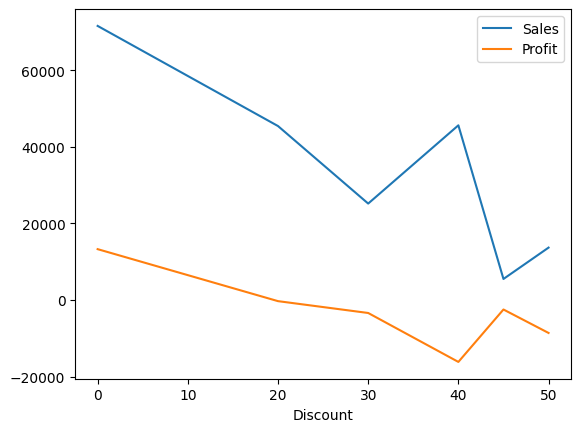

In [ ]:
p=tables.groupby("Discount")[
    ["Sales","Profit"]
].sum()
p.plot()

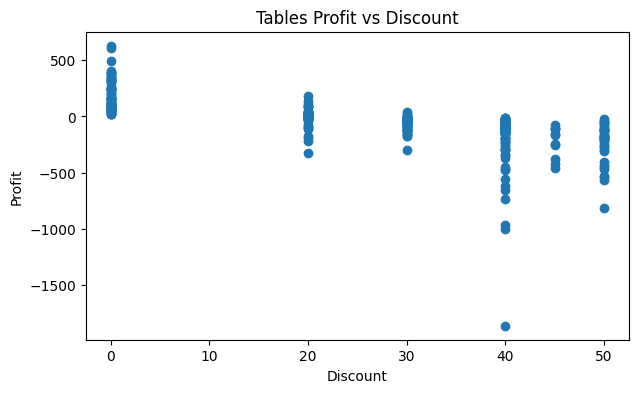

In [ ]:
# mport matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.scatter(
    tables["Discount"],
    tables["Profit"]
)

plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Tables Profit vs Discount")

plt.show()

In [ ]:
tables.groupby(
    ["Discount","Product Name"]
)[["Sales","Profit"]].sum().sort_values(
    by="Profit"
).head(20)

Sales  Profit
Discount Product Name                                                      
40.0     Chromcraft Bull-Nose Wood Oval Conference Table...  6943.0 -3008.0
         Balt Solid Wood Round Tables                        2947.0 -1523.0
         Riverside Furniture Oval Coffee Table, Oval End...  3958.0 -1188.0
         Bush Advantage Collection Racetrack Conference ...  3055.0 -1119.0
50.0     Bush Advantage Collection Racetrack Conference ...  1273.0  -814.0
40.0     Hon 94000 Series Round Tables                       1422.0  -735.0
50.0     BoxOffice By Design Rectangular and Half-Moon M...   985.0  -729.0
40.0     Bevis Oval Conference Table, Walnut                 1879.0  -720.0
50.0     Chromcraft 48" x 96" Racetrack Double Pedestal ...  1283.0  -718.0
40.0     Chromcraft Bull-Nose Wood 48" x 96" Rectangular...  1984.0  -694.0
         Hon Racetrack Conference Tables                     2048.0  -649.0
30.0     Office Impressions End Table, 20-1/2"H x 24"W x...  2764.0  -554.0
20.0     Bretford Just In Time Height-Adjustable Multi...  3340.0  -543.0
40.0     Bevis Round Bullnose 29" High Table Top             2026.0  -540.0
50.0     Bretford Just In Time Height-Adjustable Multi...   626.0  -538.0
         Hon Rectangular Conference Tables                    796.0  -526.0
         Hon 5100 Series Wood Tables                          727.0  -466.0
45.0     Bretford CR4500 Series Slim Rectangular Table       1150.0  -460.0
         Bush Advantage Collection Racetrack Conference ...   933.0  -458.0
40.0     Bretford Rectangular Conference Table Tops          1580.0  -448.0

In [ ]:
tables.groupby(
    ["Product Name","Discount"]
)["Profit"].sum().sort_values()

Product Name                                                                      Discount
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases                          40.0       -3008.0
Balt Solid Wood Round Tables                                                      40.0       -1523.0
Riverside Furniture Oval Coffee Table, Oval End Table, End Table with Drawer      40.0       -1188.0
Bush Advantage Collection Racetrack Conference Table                              40.0       -1119.0
                                                                                  50.0        -814.0
                                                                                               ...  
                                                                                  0.0          611.0
SAFCO PlanMaster Heigh-Adjustable Drafting Table Base, 43w x 30d x 30-37h, Black  0.0          629.0
Hon 5100 Series Wood Tables                                                       0.0          629.0
Hon Practical Foundations 30 x 60 Training Table, Light Gray/Charcoal             0.0          700.0
Bretford CR8500 Series Meeting Room Furniture                                     0.0          701.0
Name: Profit, Length: 196, dtype: float64

In [ ]:
tables.groupby(
    "Discount"
)["Quantity"].sum()

,Quantity
Discount,
0.0,310
20.0,281
30.0,180
40.0,292
45.0,45
50.0,133


In [ ]:
tables.groupby(
    "Order ID"
)[["Sales","Profit"]].sum().sort_values(
    by="Profit"
).head(20)

,Sales,Profit
Order ID,,
CA-2015-116638,4298.0,-1862.0
US-2014-148838,3266.0,-1125.0
US-2017-162558,2314.0,-1003.0
CA-2017-159100,1875.0,-969.0
CA-2016-109869,1273.0,-814.0
CA-2014-108609,1422.0,-735.0
CA-2017-142090,1782.0,-653.0
US-2017-110576,2065.0,-620.0
US-2017-124968,766.0,-567.0


<Axes: xlabel='Segment'>

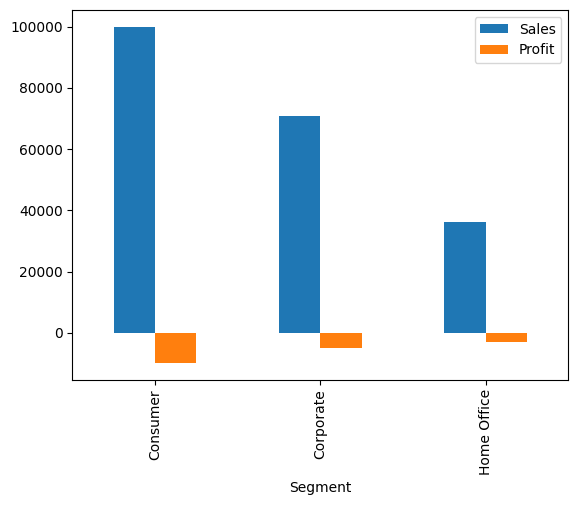

In [ ]:
u=tables.groupby(
    "Segment"
)[["Sales","Profit"]].sum()
u.plot(kind='bar')

In [ ]:
tables[
    tables["Product Name"] ==
    "Chromcraft Bull-Nose Wood Oval Conference Tables & Bases"
][[
    "Order ID",
    "Sales",
    "Profit",
    "Discount",
    "Quantity",
    "Segment"
]].sort_values(by="Profit")

,Order ID,Sales,Profit,Discount,Quantity,Segment
9639,CA-2015-116638,4298.0,-1862.0,40.0,13,Consumer
5320,US-2017-162558,2314.0,-1003.0,40.0,7,Home Office
9899,US-2014-117380,331.0,-143.0,40.0,1,Home Office
2477,CA-2017-102750,1322.0,-99.0,20.0,3,Corporate
721,CA-2016-142335,1653.0,231.0,0.0,3,Corporate


In [ ]:
df3.groupby("Region")[["Sales","Profit"]].sum()\
.sort_values(by="Profit")

,Sales,Profit
Region,,
Central,501253.0,39718.0
South,391748.0,46721.0
East,678828.0,91518.0
West,725511.0,108383.0


In [ ]:
region = df3.groupby("Region")[["Sales","Profit"]].sum()

region["Profit Margin %"] = (
    region["Profit"]/region["Sales"]
)*100

region.round(2)

,Sales,Profit,Profit Margin %
Region,,,
Central,501253.0,39718.0,7.92
East,678828.0,91518.0,13.48
South,391748.0,46721.0,11.93
West,725511.0,108383.0,14.94


In [ ]:
df3[df3["Region"]=="Central"].groupby("Category")[["Sales","Profit"]].sum().round(2)

,Sales,Profit
Category,,
Furniture,163789.0,-2867.0
Office Supplies,167032.0,8895.0
Technology,170432.0,33690.0


In [ ]:
central_sub=df3[df3["Region"]=="Central"].groupby("Sub-Category")[["Sales","Profit"]].sum().sort_values(by="Profit").round(2)
central_sub["Margin"] = (central_sub["Profit"]/central_sub["Sales"])*100
central_sub.head(15)

,Sales,Profit,Margin
Sub-Category,,,
Furnishings,15256.0,-3902.0,-25.576822
Tables,39152.0,-3561.0,-9.095321
Appliances,23581.0,-2642.0,-11.203935
Bookcases,24153.0,-1998.0,-8.272264
Machines,26800.0,-1485.0,-5.541045
Binders,56926.0,-1053.0,-1.849770
Supplies,9470.0,-659.0,-6.958817
Fasteners,776.0,237.0,30.541237
Labels,2454.0,1076.0,43.846781


In [ ]:
furniture = df3[df3["Category"] == "Furniture"]

In [ ]:
sub = furniture.groupby("Sub-Category")[["Sales","Profit"]].sum()

sub["Margin %"] = (
    sub["Profit"] /
    sub["Sales"] * 100
)

sub.sort_values("Margin %")

,Sales,Profit,Margin %
Sub-Category,,,
Tables,206967.0,-17733.0,-8.568033
Bookcases,114879.0,-3479.0,-3.028404
Chairs,328453.0,26586.0,8.094309
Furnishings,91704.0,13070.0,14.252377


In [ ]:
central = df3[df3["Region"]=="Central"]
central.groupby("Discount")[["Sales","Profit"]]\
.sum().sort_values(by="Profit")

,Sales,Profit
Discount,,
80.0,16963.0,-30546.0
30.0,64924.0,-6535.0
60.0,6649.0,-5944.0
50.0,6549.0,-4311.0
40.0,19548.0,-2666.0
32.0,14491.0,-2390.0
10.0,7735.0,1916.0
20.0,121225.0,14070.0
0.0,243169.0,76124.0


In [ ]:
df3[df3["Region"]=="Central"]\
.groupby("Segment")[["Sales","Profit"]]\
.sum().round(2)

,Sales,Profit
Segment,,
Consumer,252039.0,8571.0
Corporate,157998.0,18709.0
Home Office,91216.0,12438.0


In [ ]:
central = df[df["Region"]=="Central"]
central[
    central["Sub-Category"]=="Furnishings"
].groupby("Product Name")[["Sales","Profit"]].sum()\
.sort_values(by="Profit",ascending=True).round(2).head(20)

,Sales,Profit
Product Name,,
"Tenex Chairmat w/ Average Lip, 45"" x 53""",545.0,-681.0
Tenex Antistatic Computer Chair Mats,342.0,-427.0
"Deflect-o RollaMat Studded, Beveled Mat for Medium Pile Carpeting",406.0,-426.0
Luxo Professional Fluorescent Magnifier Lamp with Clamp-Mount Base,420.0,-357.0
Eldon ClusterMat Chair Mat with Cordless Antistatic Protection,801.0,-252.0
"Tenex Carpeted, Granite-Look or Clear Contemporary Contour Shape Chair Mats",410.0,-247.0
"Tenex ""The Solids"" Textured Chair Mats",224.0,-240.0
"Rubbermaid ClusterMat Chairmats, Mat Size- 66"" x 60"", Lip 20"" x 11"" -90 Degree Angle",599.0,-240.0
Eldon Cleatmat Plus Chair Mats for High Pile Carpets,159.0,-195.0


In [ ]:
central[
    central["Sub-Category"]=="Furnishings"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
60.0,6649.0,-5944.0
0.0,8607.0,2042.0


In [ ]:
central[
    central["Sub-Category"]=="Furnishings"
][["Product Name",
   "Discount",
   "Quantity",
   "Sales",
   "Profit"]].sort_values(by="Profit")

,Product Name,Discount,Quantity,Sales,Profit
3316,Tenex Antistatic Computer Chair Mats,60.0,5,342.0,-427.0
9592,"Tenex Chairmat w/ Average Lip, 45"" x 53""",60.0,5,303.0,-378.0
238,Luxo Professional Fluorescent Magnifier Lamp w...,60.0,5,420.0,-357.0
4229,"Deflect-o RollaMat Studded, Beveled Mat for Me...",60.0,9,332.0,-349.0
467,Eldon ClusterMat Chair Mat with Cordless Antis...,60.0,7,255.0,-312.0
...,...,...,...,...,...
5371,Luxo Professional Combination Clamp-On Lamps,0.0,3,307.0,80.0
3998,Deflect-o Glass Clear Studded Chair Mats,0.0,6,373.0,82.0
9447,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",0.0,5,477.0,138.0
2648,"3M Polarizing Task Lamp with Clamp Arm, Light ...",0.0,6,822.0,214.0


In [ ]:
west = df3[df3["Region"]=="West"]

In [ ]:
west[
    west["Sub-Category"]=="Furnishings"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
20.0,4936.0,502.0
0.0,25135.0,7144.0


In [ ]:
west[
    west["Sub-Category"]=="Furnishings"
][["Product Name",
   "Discount",
   "Quantity",
   "Sales",
   "Profit"]].sort_values(by="Profit")

,Product Name,Discount,Quantity,Sales,Profit
3882,"Eldon ""L"" Workstation Diamond Chairmat",20.0,6,365.0,-36.0
295,Eldon ClusterMat Chair Mat with Cordless Antis...,20.0,3,218.0,-25.0
7531,"Rubbermaid ClusterMat Chairmats, Mat Size- 66""...",20.0,3,266.0,-13.0
2952,"Tenex V2T-RE Standard Weight Series Chair Mat,...",20.0,2,114.0,-6.0
104,"Deflect-o DuraMat Lighweight, Studded, Beveled...",20.0,3,102.0,-4.0
...,...,...,...,...,...
5043,"Howard Miller 11-1/2"" Diameter Ridgewood Wall ...",0.0,9,467.0,192.0
4009,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",0.0,11,474.0,199.0
9348,Deflect-o DuraMat Antistatic Studded Beveled M...,0.0,8,843.0,202.0
638,Luxo Professional Fluorescent Magnifier Lamp w...,0.0,5,1049.0,273.0


In [ ]:
east = df3[df3["Region"]=="East"]

In [ ]:
east[
    east["Sub-Category"]=="Furnishings"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
20.0,11433.0,803.0
0.0,17634.0,5081.0


In [ ]:
south = df3[df3["Region"]=="South"]

In [ ]:
south[
    south["Sub-Category"]=="Furnishings"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
20.0,7239.0,853.0
0.0,10071.0,2589.0


## If the discount is not more than 20 than the central would have performed better like other regions

In [ ]:
central[central["Discount"] >= 60
][["Product Name","Sub-Category","Discount","Sales","Profit",
    "Quantity"]].sort_values(by="Profit")

,Product Name,Sub-Category,Discount,Sales,Profit,Quantity
9774,GBC DocuBind P400 Electric Binding System,Binders,80.0,2178.0,-3702.0,8
4991,Ibico EPK-21 Electric Binding System,Binders,80.0,1890.0,-2929.0,5
5310,Fellowes PB500 Electric Punch Plastic Comb Bin...,Binders,80.0,1525.0,-2288.0,6
1199,GBC DocuBind P400 Electric Binding System,Binders,80.0,1089.0,-1851.0,4
3324,GBC DocuBind TL300 Electric Binding System,Binders,80.0,897.0,-1480.0,5
...,...,...,...,...,...,...
2106,Acco 3-Hole Punch,Binders,80.0,1.0,-1.0,1
3333,"Master Caster Door Stop, Gray",Furnishings,60.0,2.0,-1.0,1
8658,Avery Durable Slant Ring Binders With Label Ho...,Binders,80.0,1.0,-1.0,1
8561,"GE General Purpose, Extra Long Life, Showcase ...",Furnishings,60.0,2.0,-1.0,2


In [ ]:
central[
    central["Sub-Category"]=="Binders"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
80.0,13582.0,-21912.0
0.0,43344.0,20859.0


In [ ]:
south[
    south["Sub-Category"]=="Binders"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
70.0,11400.0,-8411.0
0.0,25632.0,12307.0


In [ ]:
east[
    east["Sub-Category"]=="Binders"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
70.0,8186.0,-5977.0
0.0,12857.0,6140.0
20.0,32457.0,11096.0


In [ ]:
west[
    west["Sub-Category"]=="Binders"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
70.0,2976.0,-2225.0
20.0,52991.0,18323.0


In [ ]:
central[
    central["Sub-Category"]=="Tables"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
50.0,6549.0,-4311.0
30.0,15758.0,-2215.0
0.0,16845.0,2965.0


In [ ]:
south[
    south["Sub-Category"]=="Tables"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
40.0,15898.0,-6347.0
45.0,5485.0,-2493.0
0.0,22536.0,4216.0


In [ ]:
west[
    west["Sub-Category"]=="Tables"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
50.0,7124.0,-4306.0
20.0,45429.0,-309.0
0.0,32202.0,6092.0


In [ ]:
east[
    east["Sub-Category"]=="Tables"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
40.0,29720.0,-9838.0
30.0,9421.0,-1187.0


In [ ]:
#-------------------------------------

In [ ]:
east[
    east["Sub-Category"]=="Bookcases"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
50.0,7305.0,-4256.0
20.0,22779.0,352.0
0.0,13735.0,2735.0


In [ ]:
west[
    west["Sub-Category"]=="Bookcases"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
70.0,2460.0,-3898.0
0.0,5987.0,831.0
15.0,27560.0,1416.0


In [ ]:
central[
    central["Sub-Category"]=="Bookcases"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
32.0,14491.0,-2390.0
30.0,4281.0,-555.0
0.0,5381.0,947.0


In [ ]:
south[
    south["Sub-Category"]=="Bookcases"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
20.0,4064.0,-221.0
0.0,6836.0,1560.0


In [ ]:
#==============================================

In [ ]:
south[
    south["Sub-Category"]=="Machines"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
50.0,37934.0,-7635.0
0.0,15956.0,6196.0


In [ ]:
west[
    west["Sub-Category"]=="Machines"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
70.0,4490.0,-5589.0
20.0,37955.0,4971.0


<Axes: xlabel='Discount'>

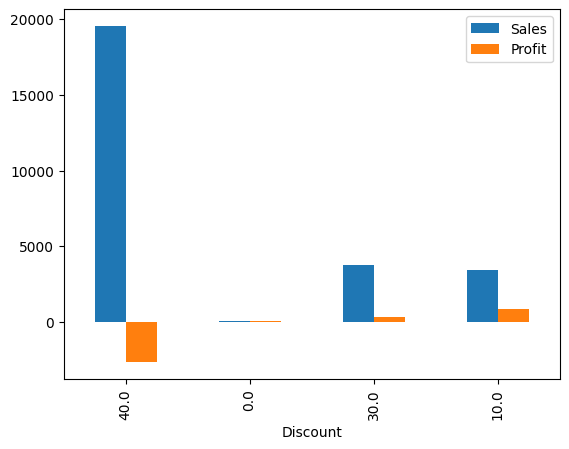

In [ ]:
f=central[
    central["Sub-Category"]=="Machines"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

f.plot(kind='bar')

In [ ]:
east[
    east["Sub-Category"]=="Machines"
].groupby("Discount")[["Sales","Profit"]].sum()\
.sort_values(by="Profit").round(2)

,Sales,Profit
Discount,,
70.0,11112.0,-13989.0
0.0,54995.0,20918.0


In [ ]:
states = ["Florida","North Carolina","Illinois",
          "Pennsylvania","Ohio","Texas"]

df3[df3["State"].isin(states)]\
.groupby("State")[["Sales","Profit"]]\
.sum().round(2)\
.sort_values(by="Profit")

,Sales,Profit
State,,
Texas,170187.0,-25715.0
Ohio,78253.0,-16963.0
Pennsylvania,116522.0,-15550.0
Illinois,80162.0,-12607.0
North Carolina,55604.0,-7495.0
Florida,89479.0,-3412.0


In [ ]:
state = df3[df3["State"].isin(states)]\
.groupby("State")[["Sales","Profit"]].sum()

state["Profit Margin %"] = (
    state["Profit"]/state["Sales"]
)*100

state.round(2)

,Sales,Profit,Profit Margin %
State,,,
Florida,89479.0,-3412.0,-3.81
Illinois,80162.0,-12607.0,-15.73
North Carolina,55604.0,-7495.0,-13.48
Ohio,78253.0,-16963.0,-21.68
Pennsylvania,116522.0,-15550.0,-13.35
Texas,170187.0,-25715.0,-15.11


In [ ]:
# INvestigate penn and ohio

In [ ]:
texas = df3[df3["State"]=="Texas"]

texas.groupby("Category")[["Sales","Profit"]]\
.sum()\
.sort_values(by="Profit")

,Sales,Profit
Category,,
Office Supplies,44488.0,-18575.0
Furniture,60586.0,-10430.0
Technology,65113.0,3290.0


In [ ]:
ohio = df3[df3["State"]=="Ohio"]

ohio.groupby("Category")[["Sales","Profit"]]\
.sum()\
.sort_values(by="Profit")

,Sales,Profit
Category,,
Technology,35675.0,-12650.0
Furniture,24196.0,-4205.0
Office Supplies,18382.0,-108.0


In [ ]:
Pennsylvania = df3[df3["State"]=="Pennsylvania"]

Pennsylvania.groupby("Category")[["Sales","Profit"]]\
.sum()\
.sort_values(by="Profit")

,Sales,Profit
Category,,
Furniture,39347.0,-7191.0
Office Supplies,34954.0,-5171.0
Technology,42221.0,-3188.0


In [ ]:
texas = df3[df3["State"]=="Texas"]

# texas.groupby("Category")[["Sales","Profit"]]\
# .sum()\
# .sort_values(by="Profit")

In [ ]:
# North Carolina
North = df3[df3["State"]=="North Carolina"]

North.groupby("Category")[["Sales","Profit"]]\
.sum()\
.sort_values(by="Profit")

,Sales,Profit
Category,,
Technology,26084.0,-3583.0
Furniture,15156.0,-3486.0
Office Supplies,14364.0,-426.0


In [ ]:
Florida = df3[df3["State"]=="Florida"]

Florida.groupby("Category")[["Sales","Profit"]]\
.sum()\
.sort_values(by="Profit")

,Sales,Profit
Category,,
Furniture,22988.0,-2259.0
Office Supplies,19523.0,-1681.0
Technology,46968.0,528.0


In [ ]:
California = df3[df3["State"]=="California"]

California.groupby("Category")[["Sales","Profit"]]\
.sum()\
.sort_values(by="Profit")

,Sales,Profit
Category,,
Furniture,156068.0,9156.0
Technology,159279.0,29459.0
Office Supplies,142381.0,37752.0


In [ ]:
New = df3[df3["State"]=="New York"]

New.groupby("Category")[["Sales","Profit"]]\
.sum()\
.sort_values(by="Profit")

,Sales,Profit
Category,,
Furniture,93383.0,5856.0
Office Supplies,90033.0,25982.0
Technology,127495.0,42180.0


In [ ]:
Utah = df3[df3["State"]=="Utah"]

Utah.groupby("Category")[["Sales","Profit"]]\
.sum()\
.sort_values(by="Profit")

,Sales,Profit
Category,,
Technology,2311.0,582.0
Furniture,4823.0,633.0
Office Supplies,4089.0,1331.0


In [ ]:
Nevada = df3[df3["State"]=="Nevada"]

Nevada.groupby("Category")[["Sales","Profit"]]\
.sum()\
.sort_values(by="Profit")

,Sales,Profit
Category,,
Technology,5137.0,512.0
Furniture,4635.0,524.0
Office Supplies,6957.0,2280.0


In [ ]:
Texas= df3[df3["State"]=="Texas"]


In [ ]:
texas.groupby("Sub-Category")[["Sales","Profit"]].sum().sort_values(by="Profit")
texas[(texas["Sub-Category"] == "Appliances")
][["Product Name","Sub-Category","Discount","Sales","Profit",
    "Quantity"]].sort_values(by="Profit")

,Product Name,Sub-Category,Discount,Sales,Profit,Quantity
4820,Hoover Upright Vacuum With Dirt Cup,Appliances,80.0,463.0,-1181.0,8
1995,3.6 Cubic Foot Counter Height Office Refrigerator,Appliances,80.0,295.0,-766.0,5
7348,3.6 Cubic Foot Counter Height Office Refrigerator,Appliances,80.0,177.0,-460.0,3
169,Kensington 7 Outlet MasterPiece Power Center,Appliances,80.0,178.0,-454.0,5
9086,Hoover Commercial Lightweight Upright Vacuum w...,Appliances,80.0,93.0,-251.0,2
176,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",Appliances,80.0,97.0,-243.0,4
7175,Belkin 5 Outlet SurgeMaster Power Centers,Appliances,80.0,87.0,-227.0,8
6136,Tripp Lite Isotel 6 Outlet Surge Protector wit...,Appliances,80.0,73.0,-187.0,6
8959,Fellowes Command Center 5-outlet power strip,Appliances,80.0,68.0,-180.0,5
203,Eureka Sanitaire Commercial Upright,Appliances,80.0,66.0,-179.0,2


In [ ]:
Texas=df3[df3["State"]=="Texas"]
Texas.groupby("Sub-Category")[["Sales","Profit"]].sum().sort_values(by="Profit")

,Sales,Profit
Sub-Category,,
Binders,9042.0,-14705.0
Appliances,2408.0,-6150.0
Furnishings,3769.0,-3312.0
Machines,19548.0,-2666.0
Chairs,26568.0,-2513.0
Bookcases,14491.0,-2390.0
Tables,15758.0,-2215.0
Supplies,4518.0,-836.0
Storage,15727.0,-761.0


In [ ]:
texas.groupby("Sub-Category")[["Sales","Profit"]].sum().sort_values(by="Profit")
texas[(texas["Sub-Category"] == "Binders")
][["Product Name","Sub-Category","Discount","Sales","Profit",
    "Quantity"]].sort_values(by="Profit")

,Product Name,Sub-Category,Discount,Sales,Profit,Quantity
9774,GBC DocuBind P400 Electric Binding System,Binders,80.0,2178.0,-3702.0,8
5310,Fellowes PB500 Electric Punch Plastic Comb Bin...,Binders,80.0,1525.0,-2288.0,6
1199,GBC DocuBind P400 Electric Binding System,Binders,80.0,1089.0,-1851.0,4
3324,GBC DocuBind TL300 Electric Binding System,Binders,80.0,897.0,-1480.0,5
8640,GBC Ibimaster 500 Manual ProClick Binding System,Binders,80.0,761.0,-1141.0,5
...,...,...,...,...,...,...
9224,Self-Adhesive Ring Binder Labels,Binders,80.0,1.0,-2.0,2
8965,Zipper Ring Binder Pockets,Binders,80.0,1.0,-2.0,2
8033,"Avery Triangle Shaped Sheet Lifters, Black, 2/...",Binders,80.0,1.0,-1.0,2
2106,Acco 3-Hole Punch,Binders,80.0,1.0,-1.0,1


In [ ]:
california=df3[df3["State"]=="California"]
california.groupby("Sub-Category")[["Sales","Profit"]].sum().sort_values(by="Profit")

,Sales,Profit
Sub-Category,,
Tables,45429.0,-309.0
Fasteners,480.0,200.0
Supplies,15721.0,862.0
Labels,2905.0,1370.0
Bookcases,27560.0,1416.0
Envelopes,3238.0,1528.0
Art,5503.0,1615.0
Chairs,63081.0,2437.0
Machines,29492.0,4175.0


In [ ]:
california=df3[df3["State"]=="California"]
california.groupby("Sub-Category")[["Sales","Profit"]].sum().sort_values(by="Profit")
california[(california["Sub-Category"] == "Binders")
][["Product Name","Sub-Category","Discount","Sales","Profit",
    "Quantity"]].sort_values(by="Profit")

,Product Name,Sub-Category,Discount,Sales,Profit,Quantity
9337,Accohide Poly Flexible Ring Binders,Binders,20.0,3.0,1.0,1
2213,Wilson Jones Easy Flow II Sheet Lifters,Binders,20.0,1.0,1.0,1
4116,Avery Reinforcements for Hole-Punch Pages,Binders,20.0,3.0,1.0,2
3234,Cardinal Holdit Business Card Pockets,Binders,20.0,4.0,1.0,1
6126,UniKeep View Case Binders,Binders,20.0,4.0,1.0,1
...,...,...,...,...,...,...
7530,Fellowes PB300 Plastic Comb Binding Machine,Binders,20.0,931.0,314.0,3
2239,Fellowes PB500 Electric Punch Plastic Comb Bin...,Binders,20.0,1017.0,381.0,1
9490,GBC ProClick 150 Presentation Binding System,Binders,20.0,2022.0,683.0,8
5990,GBC DocuBind 200 Manual Binding Machine,Binders,20.0,2357.0,884.0,7


In [ ]:
california=df3[df3["State"]=="California"]
california.groupby("Sub-Category")[["Sales","Profit"]].sum().sort_values(by="Profit")
california[(california["Sub-Category"] == "Appliances")
][["Product Name","Sub-Category","Discount","Sales","Profit",
    "Quantity"]].sort_values(by="Profit")

,Product Name,Sub-Category,Discount,Sales,Profit,Quantity
2245,"Acco Six-Outlet Power Strip, 4' Cord Length",Appliances,0.0,9.0,2.0,1
5962,Commercial WindTunnel Clean Air Upright Vacuum...,Appliances,0.0,8.0,2.0,2
5608,Commercial WindTunnel Clean Air Upright Vacuum...,Appliances,0.0,8.0,2.0,2
4593,Hoover Replacement Belts For Soft Guard & Comm...,Appliances,0.0,8.0,2.0,2
5821,Hoover Commercial Soft Guard Upright Vacuum An...,Appliances,0.0,8.0,2.0,1
...,...,...,...,...,...,...
2476,Honeywell Enviracaire Portable HEPA Air Cleane...,Appliances,0.0,1101.0,430.0,4
5434,Sanyo Counter Height Refrigerator with Crisper...,Appliances,0.0,1641.0,459.0,5
6838,Sanyo Counter Height Refrigerator with Crisper...,Appliances,0.0,1641.0,459.0,5
1711,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",Appliances,0.0,1702.0,511.0,14


In [ ]:
ohio=df3[df3["State"]=="Ohio"]
ohio.groupby("Sub-Category")[["Sales","Profit"]].sum().sort_values(by="Profit")
# ohio[ohio["Sub-Category"]=="Appliances"][["Product Name","Sub-Category","Discount","Sales","Profit",
#     "Quantity"]].sort_values(by="Profit")

,Sales,Profit
Sub-Category,,
Machines,8978.0,-11770.0
Phones,14634.0,-2778.0
Tables,7888.0,-2715.0
Binders,1917.0,-1401.0
Bookcases,2076.0,-1360.0
Chairs,10143.0,-649.0
Storage,7266.0,-275.0
Supplies,480.0,-83.0
Labels,162.0,56.0


In [ ]:
ohio=df3[df3["State"]=="Ohio"]
ohio.groupby("Sub-Category")[["Sales","Profit"]].sum().sort_values(by="Profit")
ohio[ohio["Sub-Category"]=="Phones"][["Product Name","Sub-Category","Discount","Sales","Profit",
    "Quantity"]].sort_values(by="Profit")

,Product Name,Sub-Category,Discount,Sales,Profit,Quantity
7509,Samsung Galaxy S III - 16GB - pebble blue (T-M...,Phones,40.0,1890.0,-378.0,9
3044,Cisco Unified IP Phone 7945G VoIP phone,Phones,40.0,1023.0,-256.0,5
3587,Apple iPhone 5,Phones,40.0,1170.0,-253.0,3
5016,Samsung Galaxy S4,Phones,40.0,1502.0,-250.0,4
3833,Samsung Galaxy S III - 16GB - pebble blue (T-M...,Phones,40.0,1050.0,-210.0,5
1829,Apple iPhone 5,Phones,40.0,780.0,-169.0,2
6501,Polycom CX300 Desktop Phone USB VoIP phone,Phones,40.0,540.0,-108.0,6
2537,Polycom VVX 310 VoIP phone,Phones,40.0,432.0,-101.0,4
1865,Jabra SPEAK 410 Multidevice Speakerphone,Phones,40.0,371.0,-93.0,3
2221,Polycom SoundStation2 EX Conference phone,Phones,40.0,486.0,-89.0,2


In [ ]:
ohio=df3[df3["State"]=="Ohio"]
ohio.groupby("Sub-Category")[["Sales","Profit"]].sum().sort_values(by="Profit")
ohio[ohio["Sub-Category"]=="Machines"][["Product Name","Sub-Category","Discount","Sales","Profit",
    "Quantity"]].sort_values(by="Profit")

,Product Name,Sub-Category,Discount,Sales,Profit,Quantity
7772,Cubify CubeX 3D Printer Double Head Print,Machines,70.0,4500.0,-6600.0,5
3151,Cubify CubeX 3D Printer Double Head Print,Machines,70.0,1800.0,-2640.0,2
215,Cisco 9971 IP Video Phone Charcoal,Machines,70.0,1188.0,-950.0,9
2628,Epson TM-T88V Direct Thermal Printer - Monochr...,Machines,70.0,653.0,-936.0,7
223,Swingline SM12-08 MicroCut Jam Free Shredder,Machines,70.0,480.0,-384.0,4
9562,Cisco 8961 IP Phone Charcoal,Machines,70.0,225.0,-165.0,3
8872,Hewlett-Packard Deskjet F4180 All-in-One Color...,Machines,70.0,102.0,-71.0,2
4823,Texas Instrument TI-15 Fraction Calculator,Machines,70.0,30.0,-24.0,7


In [ ]:
print(states)

['Florida', 'North Carolina', 'Illinois', 'Pennsylvania', 'Ohio', 'Texas']


In [ ]:
states= ['Florida', 'North Carolina', 'Illinois', 'Pennsylvania', 'Ohio', 'Texas','California','Arizona']
for state in states:
    temp= df3[df3["State"]==state]
    print(f"\n{state}")
    print(temp.groupby("Sub-Category")[["Sales","Profit"]].sum().sort_values(by="Profit"))


Florida
                Sales  Profit
Sub-Category                 
Binders        3691.0 -2764.0
Tables         5485.0 -2493.0
Machines      24573.0 -1975.0
Storage        7420.0  -204.0
Supplies       1068.0  -198.0
Bookcases      2587.0  -116.0
Chairs        11168.0   -40.0
Fasteners        49.0    16.0
Envelopes       211.0    74.0
Art             713.0    77.0
Labels          388.0   138.0
Appliances     3557.0   350.0
Furnishings    3748.0   390.0
Copiers        1440.0   402.0
Accessories    5861.0   749.0
Paper          2426.0   830.0
Phones        15094.0  1352.0

North Carolina
                Sales  Profit
Sub-Category                 
Machines      12621.0 -5385.0
Tables         9683.0 -3684.0
Binders        2562.0 -2009.0
Bookcases       959.0   -98.0
Storage        3439.0   -87.0
Supplies        302.0   -28.0
Fasteners        67.0    22.0
Art             603.0    77.0
Labels          230.0    77.0
Copiers         960.0   120.0
Envelopes       431.0   139.0
Chairs         

In [ ]:
a="""select *
from(
select category,"Sub-Category", sum(Profit) as profit,
(profit/sales)*100 as margin
from store
group by category,"Sub-Category"
) t
order by margin desc
"""
display(pd.read_sql(a, conn3))

,category,Sub-Category,profit,margin
0,Office Supplies,Labels,5558.0,46.666667
1,Office Supplies,Fasteners,952.0,40.000000
2,Technology,Copiers,55618.0,35.000000
3,Office Supplies,Envelopes,6956.0,33.333333
4,Office Supplies,Binders,30200.0,31.578947
5,Office Supplies,Paper,34053.0,31.250000
6,Furniture,Chairs,26586.0,30.054645
7,Office Supplies,Appliances,18132.0,29.565217
8,Furniture,Furnishings,13070.0,28.571429
9,Office Supplies,Art,6529.0,28.571429


In [ ]:
sub = df.groupby("Sub-Category")[["Sales","Profit"]].sum()

sub["Profit Margin %"] = (
    sub["Profit"] / sub["Sales"]
) * 100

sub.sort_values(by="Profit Margin %", ascending=False).round(2)

,Sales,Profit,Profit Margin %
Sub-Category,,,
Labels,12505.0,5558.0,44.45
Paper,78475.0,34053.0,43.39
Envelopes,16477.0,6956.0,42.22
Copiers,149530.0,55618.0,37.20
Fasteners,3024.0,952.0,31.48
Accessories,167400.0,41928.0,25.05
Art,27136.0,6529.0,24.06
Appliances,107537.0,18132.0,16.86
Binders,203425.0,30200.0,14.85


In [ ]:
labels= df3[df3["Sub-Category"]=="Labels"]
labels.groupby("Discount")["Product ID"].count()

,Product ID
Discount,
0.0,239
20.0,125


In [ ]:
Paper= df3[df3["Sub-Category"]=="Paper"]
Paper.groupby("Discount")["Product ID"].count()

,Product ID
Discount,
0.0,857
20.0,513


In [ ]:
Copiers= df3[df3["Sub-Category"]=="Copiers"]
Copiers.groupby("Discount")["Product ID"].count()

,Product ID
Discount,
0.0,22
20.0,37
40.0,9


In [ ]:
Accessories= df3[df3["Sub-Category"]=="Accessories"]
Accessories.groupby("Discount")["Product ID"].count()

,Product ID
Discount,
0.0,471
20.0,304


In [ ]:
Furnishings= df3[df3["Sub-Category"]=="Furnishings"]
Furnishings.groupby("Discount")["Product ID"].count()

,Product ID
Discount,
0.0,571
20.0,248
60.0,138


In [ ]:
Chairs= df3[df3["Sub-Category"]=="Chairs"]
Chairs.groupby("Discount")["Product ID"].count()

,Product ID
Discount,
0.0,133
10.0,76
20.0,250
30.0,158


In [ ]:
#  Sean Miller                -603
# 1         Becky Martin                -588
# 2       Grant Thornton                -588
# 3     Natalie Fritzler                -570
# 4         Sean Braxton                -568
# 5         Peter Fuller                -557
# 6     Zuschuss Carroll                -557
# 7          Joseph Holt                -544
# 8         Joseph Airdo                -527
# 9        Cindy Stewart                -524
# 10      Christine Phan                -518
# 11     Victoria Wilson
# 12        Tom Prescott

In [ ]:
customer = df3[df3["Customer Name"] == "Sean Miller"]

customer[[
    "Customer Name",
    "Order Date",
    "Region",
    "State",
    "Category",
    "Sub-Category",
    "Product Name",
    "Discount",
    "Sales",
    "Profit",
    "Quantity"
]].sort_values(by="Profit")

,Customer Name,Order Date,Region,State,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity
2697,Sean Miller,2014-03-18,South,Florida,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,50.0,22638.0,-1811.0,6
9189,Sean Miller,2015-08-21,East,Pennsylvania,Office Supplies,Storage,"SAFCO Commercial Wire Shelving, Black",20.0,663.0,-166.0,6
9190,Sean Miller,2015-08-21,East,Pennsylvania,Office Supplies,Binders,GBC DocuBind P100 Manual Binding Machine,70.0,100.0,-83.0,2
2696,Sean Miller,2014-03-18,South,Florida,Technology,Machines,Hewlett-Packard Deskjet 6540 Color Inkjet Printer,50.0,821.0,-16.0,4
9187,Sean Miller,2015-08-21,East,Pennsylvania,Office Supplies,Supplies,Staple remover,20.0,3.0,-1.0,2
2699,Sean Miller,2014-03-18,South,Florida,Office Supplies,Art,Avery Fluorescent Highlighter Four-Color Set,20.0,8.0,1.0,3
2266,Sean Miller,2017-10-12,South,North Carolina,Office Supplies,Paper,Xerox 1989,20.0,8.0,3.0,2
9188,Sean Miller,2015-08-21,East,Pennsylvania,Technology,Accessories,Sabrent 4-Port USB 2.0 Hub,20.0,22.0,4.0,4
7853,Sean Miller,2015-12-25,West,California,Office Supplies,Paper,Xerox 1949,0.0,10.0,5.0,2
2701,Sean Miller,2014-03-18,South,Florida,Office Supplies,Fasteners,Staples,20.0,19.0,6.0,3


In [ ]:
customer = df3[df3["Customer Name"] == "Becky Martin"]

customer[[
    "Customer Name",
    "Order Date",
    "Region",
    "State",
    "Category",
    "Sub-Category",
    "Product Name",
    "Discount",
    "Sales",
    "Profit",
    "Quantity"
]].sort_values(by="Profit")

,Customer Name,Order Date,Region,State,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity
165,Becky Martin,2014-09-08,Central,Texas,Technology,Machines,Lexmark MX611dhe Monochrome Laser Printer,40.0,8160.0,-1360.0,8
169,Becky Martin,2014-09-08,Central,Texas,Office Supplies,Appliances,Kensington 7 Outlet MasterPiece Power Center,80.0,178.0,-454.0,5
166,Becky Martin,2014-09-08,Central,Texas,Office Supplies,Storage,Space Solutions HD Industrial Steel Shelving.,20.0,276.0,-59.0,3
167,Becky Martin,2014-09-08,Central,Texas,Furniture,Chairs,SAFCO Arco Folding Chair,30.0,1740.0,-25.0,9
9068,Becky Martin,2016-09-02,West,Washington,Furniture,Chairs,"Global Leather Task Chair, Black",20.0,216.0,-3.0,3
1224,Becky Martin,2016-12-04,East,New York,Office Supplies,Binders,Peel & Stick Add-On Corner Pockets,20.0,2.0,1.0,1
164,Becky Martin,2014-09-08,Central,Texas,Office Supplies,Art,BIC Brite Liner Highlighters,20.0,10.0,3.0,3
1226,Becky Martin,2016-12-04,East,New York,Office Supplies,Storage,Carina Media Storage Towers in Natural & Black,0.0,183.0,4.0,3
168,Becky Martin,2014-09-08,Central,Texas,Office Supplies,Art,Sanford Liquid Accent Highlighters,20.0,32.0,7.0,6
170,Becky Martin,2014-09-08,Central,Texas,Technology,Phones,JBL Micro Wireless Portable Bluetooth Speaker,20.0,144.0,9.0,3


In [ ]:
customer = df3[df3["Customer Name"] == "Natalie Fritzler"]

customer[[
    "Customer Name",
    "Order Date",
    "Region",
    "State",
    "Category",
    "Sub-Category",
    "Product Name",
    "Discount",
    "Sales",
    "Profit",
    "Quantity"
]].sort_values(by="Profit")

,Customer Name,Order Date,Region,State,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity
3151,Natalie Fritzler,2015-12-15,East,Ohio,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,70.0,1800.0,-2640.0,2
457,Natalie Fritzler,2016-09-26,Central,Illinois,Furniture,Chairs,Hon 4700 Series Mobuis Mid-Back Task Chairs wi...,30.0,748.0,-96.0,3
9486,Natalie Fritzler,2017-10-12,East,West Virginia,Furniture,Tables,"Chromcraft 48"" x 96"" Racetrack Double Pedestal...",30.0,673.0,-77.0,3
3152,Natalie Fritzler,2015-12-15,East,Ohio,Technology,Phones,Panasonic KX TS3282W Corded phone,40.0,102.0,-17.0,2
6055,Natalie Fritzler,2016-08-18,Central,Texas,Office Supplies,Binders,GBC Wire Binding Combs,80.0,2.0,-3.0,1
458,Natalie Fritzler,2016-09-26,Central,Illinois,Office Supplies,Envelopes,Staple envelope,20.0,9.0,3.0,2
5632,Natalie Fritzler,2014-02-11,South,Virginia,Office Supplies,Binders,Wilson Jones Leather-Like Binders with DublLoc...,0.0,17.0,8.0,2
9829,Natalie Fritzler,2017-07-16,South,North Carolina,Furniture,Chairs,"Global Fabric Manager's Chair, Dark Gray",20.0,242.0,15.0,3
6056,Natalie Fritzler,2016-08-18,Central,Texas,Office Supplies,Paper,Advantus Motivational Note Cards,20.0,84.0,30.0,8
3153,Natalie Fritzler,2015-12-15,East,Ohio,Furniture,Furnishings,"Howard Miller 13"" Diameter Goldtone Round Wall...",20.0,263.0,69.0,7


In [ ]:

customer = df3[df3["Customer Name"] == "Grant Thornton"]

customer[[
    "Customer Name",
    "Order Date",
    "Region",
    "State",
    "Category",
    "Sub-Category",
    "Product Name",
    "Discount",
    "Sales",
    "Profit",
    "Quantity"
]].sort_values(by="Profit")

,Customer Name,Order Date,Region,State,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity
683,Grant Thornton,2017-11-04,South,North Carolina,Technology,Machines,Cubify CubeX 3D Printer Triple Head Print,50.0,8000.0,-3840.0,4
2141,Grant Thornton,2014-06-06,East,New York,Furniture,Tables,"Chromcraft Bull-Nose Wood 48"" x 96"" Rectangula...",40.0,992.0,-347.0,3
2140,Grant Thornton,2014-06-06,East,New York,Office Supplies,Supplies,Acme Office Executive Series Stainless Steel T...,0.0,17.0,4.0,2
3309,Grant Thornton,2015-11-05,East,New York,Office Supplies,Binders,"Wilson Jones 1"" Hanging DublLock Ring Binders",20.0,25.0,9.0,6
684,Grant Thornton,2017-11-04,South,North Carolina,Office Supplies,Appliances,Eureka The Boss Plus 12-Amp Hard Box Upright V...,20.0,167.0,15.0,2
2139,Grant Thornton,2014-06-06,East,New York,Office Supplies,Binders,Wilson Jones Century Plastic Molded Ring Binders,20.0,150.0,50.0,9


In [ ]:
top_customers = [
    "Sean Miller",
    "Becky Martin",
    "Grant Thornton",
    "Natalie Fritzler",
    "Sean Braxton",
    "Peter Fuller",
    "Zuschuss Carroll",
    "Joseph Holt",
    "Joseph Airdo",
    "Cindy Stewart"
]

df[df["Customer Name"].isin(top_customers)] \
.groupby("Sub-Category")[["Sales","Profit","Quantity"]] \
.sum() \
.sort_values(by="Profit")
# (dd["margin"]=(df["Profit"]/df["Sales"])*100)

,Sales,Profit,Quantity
Sub-Category,,,
Machines,52978.0,-18356.0,59
Tables,9858.0,-1966.0,36
Binders,4179.0,-1485.0,85
Appliances,2134.0,-1296.0,47
Supplies,4736.0,-1040.0,18
Storage,2738.0,-218.0,48
Fasteners,80.0,25.0,17
Envelopes,126.0,56.0,11
Labels,137.0,64.0,20
